In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from numpy.fft import fftfreq
import ipywidgets as widgets
from IPython.display import display
import sys

import mlx.core as mx

sys.path.insert(0, 'XSmurfWrapper')
import xsmurf_wrapper as xsm

print(f"MLX: {mx.__version__}, xsmurf: {xsm.__version__}")
# --- Shear-zone additions ---
try:
    from orix.quaternion import Orientation, Rotation
    from orix.quaternion.symmetry import D2, D3, C1
    _HAS_ORIX = True
    print(f'orix available for rotation + symmetry ops')
except ImportError:
    _HAS_ORIX = False
    print('orix not in this env — rotation + KAM fall back to pure-numpy path')

JOSEPHINE_ROTATION_XLSX = Path('EBSD/Josephine_Peridotite_Olivine/1365-3_RotationMetadata.xlsx')
EBSD_DIR = Path('/Users/amasaryk/projects/Creep/wavelet/EBSD')


MLX: 0.31.1, xsmurf: 0.1.0
orix available for rotation + symmetry ops


In [2]:
def compute_scales(n_oct, n_vox, a_min=1):
    norm = 6.0 / 0.86
    return [a_min * (2.0 ** (o + v / n_vox)) * norm
            for o in range(n_oct) for v in range(n_vox)]

def _build_wavelet_filters_f32(kx, ky, scale, wavelet='gaussian'):
    sx = kx * scale
    sy = ky * scale
    gauss = mx.exp(-(sx * sx + sy * sy))
    zero = mx.zeros_like(gauss)
    def to_complex(r, i):
        return mx.stack([r, i], axis=-1).view(mx.complex64).squeeze(-1)
    if wavelet == 'mexican':
        k2 = sx * sx + sy * sy
        return {
            'dx':  to_complex(zero, sx * k2 * gauss),
            'dy':  to_complex(zero, sy * k2 * gauss),
            'dxx':  to_complex(-sx * sx * k2 * gauss, zero),
            'dxy':  to_complex(-sy * sx * k2 * gauss, zero),
            'dyy':  to_complex(-sy * sy * k2 * gauss, zero),
            'dxxx': to_complex(zero, -sx * sx * sx * k2 * gauss),
            'dxxy': to_complex(zero, -sx * sx * sy * k2 * gauss),
            'dxyy': to_complex(zero, -sx * sy * sy * k2 * gauss),
            'dyyy': to_complex(zero, -sy * sy * sy * k2 * gauss),
        }
    else:
        return {
            'dx':  to_complex(zero, sx * gauss),
            'dy':  to_complex(zero, sy * gauss),
            'dxx':  to_complex(-sx * sx * gauss, zero),
            'dxy':  to_complex(-sy * sx * gauss, zero),
            'dyy':  to_complex(-sy * sy * gauss, zero),
            'dxxx': to_complex(zero, -sx * sx * sx * gauss),
            'dxxy': to_complex(zero, -sx * sx * sy * gauss),
            'dxyy': to_complex(zero, -sx * sy * sy * gauss),
            'dyyy': to_complex(zero, -sy * sy * sy * gauss),
        }

def cwt_2d_f32(image, scales, pad=32, derivs='first', wavelet='gaussian', verbose=True):
    """2D CWT via MLX FFT. derivs='first' for dx,dy only; 'all' for up to 3rd order."""
    ny, nx = image.shape
    padded = np.pad(image, pad, mode='reflect').astype(np.float32)
    ny_p, nx_p = padded.shape
    crop = (slice(pad, pad + ny), slice(pad, pad + nx))
    kx_np = fftfreq(nx_p).astype(np.float32)
    ky_np = fftfreq(ny_p).astype(np.float32)
    KX_np, KY_np = np.meshgrid(kx_np, ky_np)
    KX, KY = mx.array(KX_np), mx.array(KY_np)
    image_fft = mx.fft.fft2(mx.array(padded))
    if derivs == 'first':
        names = ['dx', 'dy']
    else:
        names = ['dx', 'dy', 'dxx', 'dxy', 'dyy', 'dxxx', 'dxxy', 'dxyy', 'dyyy']
    n_scales = len(scales)
    result = {n: np.zeros((n_scales, ny, nx), dtype=np.float32) for n in names}
    result['mod'] = np.zeros((n_scales, ny, nx), dtype=np.float32)
    result['arg'] = np.zeros((n_scales, ny, nx), dtype=np.float32)
    for i, scale in enumerate(scales):
        filters = _build_wavelet_filters_f32(KX, KY, scale, wavelet=wavelet)
        for name in names:
            conv = mx.fft.ifft2(image_fft * filters[name])
            result[name][i] = np.array(conv.real)[crop]
        dx_s, dy_s = result['dx'][i], result['dy'][i]
        result['mod'][i] = np.sqrt(dx_s * dx_s + dy_s * dy_s)
        result['arg'][i] = np.arctan2(dy_s, dx_s).astype(np.float32)
        if verbose and (i % max(1, n_scales // 4) == 0 or i == n_scales - 1):
            print(f'  Scale {i}/{n_scales-1}: a={scale:.1f}')
    mx.eval()
    return result

def tensor_svd_3x2(gx1, gy1, gx2, gy2, gx3, gy3):
    """SVD of 3x2 Jacobian at every pixel via closed-form J^T J eigenvalues."""
    a = gx1*gx1 + gx2*gx2 + gx3*gx3
    b = gx1*gy1 + gx2*gy2 + gx3*gy3
    d = gy1*gy1 + gy2*gy2 + gy3*gy3
    trace = a + d
    det = a * d - b * b
    disc = np.sqrt(np.maximum((trace / np.float32(2))**2 - det, np.float32(0)))
    lambda1 = trace / np.float32(2) + disc
    lambda2 = np.maximum(trace / np.float32(2) - disc, np.float32(0))
    sigma_max = np.sqrt(np.maximum(lambda1, np.float32(0))).astype(np.float32)
    sigma_min = np.sqrt(lambda2).astype(np.float32)
    vx = lambda1 - d
    vy = b
    vnorm = np.sqrt(vx**2 + vy**2) + np.float32(1e-30)
    arg = np.arctan2(vy / vnorm, vx / vnorm).astype(np.float32)
    return sigma_max, sigma_min, arg

from xsmurf_wrapper.wavelet import gkapa_numpy, gkapap_numpy


print('CWT (first + all derivs) + tensor SVD + kapa/kapap functions defined')


CWT (first + all derivs) + tensor SVD + kapa/kapap functions defined


In [3]:
%matplotlib widget


In [4]:
def read_ctf(filepath):
    """Read an Oxford Instruments .ctf (Channel Text File) EBSD dataset.
    
    Returns
    -------
    data : dict with 2D arrays for each field + metadata dict
    """
    filepath = Path(filepath)
    with open(filepath, 'r', errors='replace') as f:
        lines = f.readlines()

    meta = {'filepath': str(filepath), 'name': filepath.stem}
    phases = {}
    header_line = None

    for i, line in enumerate(lines):
        stripped = line.strip()
        if stripped.startswith('XCells'):
            meta['xcells'] = int(stripped.split('\t')[1])
        elif stripped.startswith('YCells'):
            meta['ycells'] = int(stripped.split('\t')[1])
        elif stripped.startswith('XStep'):
            meta['xstep'] = float(stripped.split('\t')[1])
        elif stripped.startswith('YStep'):
            meta['ystep'] = float(stripped.split('\t')[1])
        elif stripped.startswith('Phases'):
            n_phases = int(stripped.split('\t')[1])
            for j in range(1, n_phases + 1):
                phases[j] = lines[i + j].strip().split('\t')
            meta['phases'] = phases
            meta['n_phases'] = n_phases
        elif stripped.startswith('Phase\tX\tY'):
            header_line = i
            break

    if header_line is None:
        raise ValueError(f"Could not find data header in {filepath}")

    # Read tabular data
    df = pd.read_csv(filepath, sep='\t', skiprows=header_line, engine='python',
                     on_bad_lines='skip')
    
    nx, ny = meta['xcells'], meta['ycells']
    expected = nx * ny
    actual = len(df)
    if actual != expected:
        print(f"  Warning: expected {expected} rows ({nx}x{ny}), got {actual}")
        # Truncate or pad
        if actual > expected:
            df = df.iloc[:expected]
        else:
            nx_adj = actual // ny if ny > 0 else nx
            meta['xcells'] = nx_adj
            nx = nx_adj

    data = {'meta': meta}
    shape = (ny, nx)
    for col in df.columns:
        try:
            data[col] = df[col].values.reshape(shape)
        except ValueError:
            data[col] = df[col].values  # keep flat if reshape fails

    # Convenience aliases
    data['euler1'] = data.get('Euler1', None)
    data['euler2'] = data.get('Euler2', None)
    data['euler3'] = data.get('Euler3', None)
    data['bc'] = data.get('BC', None)
    data['bs'] = data.get('BS', None)
    data['mad'] = data.get('MAD', None)
    data['phase'] = data.get('Phase', None)

    print(f"  Loaded {filepath.name}: {nx} x {ny}, step={meta.get('xstep','?')} µm, "
          f"{meta.get('n_phases','?')} phases")
    return data
# --- Oxford Instruments Channel 5 .cpr/.crc binary reader ---
# Pure-numpy reader for .cpr (ASCII INI metadata) + .crc (binary data) pairs.
# Field code mapping taken from defdap.file_readers.OxfordBinaryLoader source.
# Unlike defdap's loader, this one does NOT construct a crystal Phase object
# so it works for any Laue group (including trigonal quartz, monoclinic
# feldspars, etc.) that the narrow defdap Phase class would reject.

import re as _re_cpr

_CPR_FIELD_LOOKUP = {
    3:  ('ph1',      'float32'),   # Euler1 phi1 (rad)
    4:  ('phi',      'float32'),   # Euler2 Phi  (rad)
    5:  ('ph2',      'float32'),   # Euler3 phi2 (rad)
    6:  ('MAD',      'float32'),   # mean angular deviation
    7:  ('BC',       'uint8'),     # band contrast
    8:  ('BS',       'uint8'),     # band slope
    10: ('numBands', 'uint8'),
    11: ('AFI',      'uint8'),
    12: ('IB6',      'float32'),
}


def _parse_cpr_ini(cpr_path):
    text = Path(cpr_path).read_text(errors='replace')
    groups = {}
    current = None
    group_re = _re_cpr.compile(r'^\[(.+)\]\s*$')
    for line in text.splitlines():
        line = line.strip()
        if not line or line.startswith(';'):
            continue
        m = group_re.match(line)
        if m:
            current = m.group(1)
            groups.setdefault(current, {})
            continue
        if current is None:
            continue
        if '=' in line:
            k, v = line.split('=', 1)
            groups[current][k.strip()] = v.strip()
    return groups


def read_cpr(filepath):
    """Read an Oxford Instruments .cpr/.crc file pair.

    Returns the same dict shape as read_ctf():
        meta          dict with xcells, ycells, xstep, ystep, phases, n_phases, name
        euler1/2/3    (ny, nx) float32 arrays in DEGREES
        phase         (ny, nx) uint8 array
        bc, bs, mad   (ny, nx) arrays if present
        Plus any EDX windows as EDX_<element> keys.
    """
    filepath = Path(filepath)
    cpr_path = filepath.with_suffix('.cpr')
    crc_path = filepath.with_suffix('.crc')
    if not cpr_path.exists():
        raise FileNotFoundError(f"CPR header not found: {cpr_path}")
    if not crc_path.exists():
        raise FileNotFoundError(f"CRC binary not found: {crc_path}")

    groups = _parse_cpr_ini(cpr_path)

    # Grid & step
    job = groups.get('Job', {})
    nx = int(job['xCells'])
    ny = int(job['yCells'])
    xstep = float(job.get('GridDistX', 1.0))
    ystep = float(job.get('GridDistY', xstep))

    # Phases: assemble ctf-like metadata so downstream cells keep working
    pg = groups.get('Phases', {})
    n_phases = int(pg.get('Count', 0))
    phases = {}
    for i in range(1, n_phases + 1):
        pi = groups.get(f'Phase{i}', {})
        lattice = '{};{};{}'.format(pi.get('a', '?'), pi.get('b', '?'), pi.get('c', '?'))
        angles = '{};{};{}'.format(pi.get('alpha', '?'), pi.get('beta', '?'), pi.get('gamma', '?'))
        phases[i] = [lattice, angles,
                     pi.get('StructureName', f'phase_{i}'),
                     pi.get('LaueGroup', '?'), pi.get('SpaceGroup', '?')]

    # EDX window names (field codes 100+i)
    edx_names = {}
    edx_group = groups.get('EDX Windows', {})
    if edx_group:
        n_edx = int(edx_group.get('Count', 0))
        for i in range(1, n_edx + 1):
            key = edx_group.get(f'Window{i}', f'edx{i}')
            edx_names[100 + i] = key

    # Build the binary record dtype from the [Fields] section
    fg = groups.get('Fields', {})
    n_fields = int(fg.get('Count', 0))
    dtype_items = [('phase', 'uint8')]   # phase is always first, uint8
    unknown = 0
    for i in range(1, n_fields + 1):
        code = int(fg[f'Field{i}'])
        if code in _CPR_FIELD_LOOKUP:
            dtype_items.append(_CPR_FIELD_LOOKUP[code])
        elif code in edx_names:
            dtype_items.append((f'EDX_{edx_names[code]}', 'float32'))
        else:
            unknown += 1
            dtype_items.append((f'unknown_{unknown}_code{code}', 'float32'))
            print(f'  warning: unknown CPR field code {code}, guessing float32')
    record_dtype = np.dtype(dtype_items)

    # Load binary
    raw = np.fromfile(str(crc_path), dtype=record_dtype, count=nx * ny)
    if raw.size != nx * ny:
        raw = raw[:nx * ny]
        print(f'  warning: CRC short read ({raw.size} records)')

    shape = (ny, nx)
    data = {'meta': {
        'filepath': str(filepath),
        'name': filepath.stem,
        'xcells': nx, 'ycells': ny,
        'xstep': xstep, 'ystep': ystep,
        'phases': phases, 'n_phases': n_phases,
        'format': 'cpr',
    }}

    data['phase'] = raw['phase'].reshape(shape)

    # CPR stores Euler in radians; convert to degrees to match ctf convention
    for raw_key, deg_key in [('ph1', 'euler1'), ('phi', 'euler2'), ('ph2', 'euler3')]:
        if raw_key in raw.dtype.names:
            data[deg_key] = np.rad2deg(raw[raw_key].reshape(shape)).astype(np.float32)

    if 'MAD' in raw.dtype.names: data['mad'] = raw['MAD'].reshape(shape)
    if 'BC'  in raw.dtype.names: data['bc']  = raw['BC'].reshape(shape)
    if 'BS'  in raw.dtype.names: data['bs']  = raw['BS'].reshape(shape)
    if 'numBands' in raw.dtype.names: data['bands'] = raw['numBands'].reshape(shape)
    for name in raw.dtype.names:
        if name.startswith('EDX_'):
            data[name] = raw[name].reshape(shape)

    print(f'  CPR: {nx}x{ny} @ {xstep} um, {n_phases} phases, {len(dtype_items)} fields')
    return data


def read_ebsd(filepath):
    """Dispatch to the right EBSD reader based on file extension."""
    filepath = Path(filepath)
    ext = filepath.suffix.lower()
    if ext == '.ctf':
        return read_ctf(filepath)
    elif ext in ('.cpr', '.crc'):
        return read_cpr(filepath)
    else:
        raise ValueError(f"Unsupported EBSD extension: {ext} (expected .ctf or .cpr/.crc)")


In [5]:
EBSD_DIR = Path('EBSD')

# --- Loadable files: .ctf (ASCII) and .cpr (Oxford binary via read_cpr) ---
ctf_files = sorted(EBSD_DIR.rglob('*.ctf'))
cpr_files = sorted(EBSD_DIR.rglob('*.cpr'))
ebsd_files = sorted(ctf_files + cpr_files, key=lambda p: (p.parts[:-1], p.name))

# Shear-zone folder tags
SHEAR_ZONE_TAGS = {
    'Calamita_Elba_Quartzite':           ('[CAL]', 'Calamita quartzite'),
    'Kuckaus_Namibia_Feldspar_Mylonite': ('[KUC]', 'Kuckaus polymineralic mylonite'),
    'Josephine_Peridotite_Olivine':      ('[JOS]', 'Josephine peridotite'),
}

def _tag(path):
    rel = path.relative_to(EBSD_DIR)
    root = rel.parts[0] if rel.parts else ''
    return SHEAR_ZONE_TAGS.get(root, ('[...]', root))[0]

labels = []
for p in ebsd_files:
    rel = p.relative_to(EBSD_DIR)
    labels.append(f'{_tag(p)} {rel}  [{p.suffix[1:]}]')

print(f'Found {len(ebsd_files)} EBSD files ({len(ctf_files)} CTF + {len(cpr_files)} CPR):\n')
from collections import defaultdict
by_tag = defaultdict(list)
for i, p in enumerate(ebsd_files):
    by_tag[_tag(p)].append(i)
for tag, idxs in by_tag.items():
    print(f'  {tag}  ({len(idxs)} files)')
    for i in idxs:
        rel = ebsd_files[i].relative_to(EBSD_DIR)
        print(f'    [{i:3d}] {rel}  [{ebsd_files[i].suffix[1:]}]')
    print()


Found 61 EBSD files (54 CTF + 7 CPR):

  [...]  (24 files)
    [  0] 2013-05-16_Pearce_Mark_6535v1/data/Overview_Map_Processed.ctf  [ctf]
    [  1] 2013-05-16_Pearce_Mark_6535v1/data/Overview_Map_Raw.ctf  [ctf]
    [  2] 2013-05-16_Pearce_Mark_6535v1/data/Siderite_Detail_Processed.ctf  [ctf]
    [  3] 2013-05-16_Pearce_Mark_6535v1/data/Siderite_Detail_Raw.ctf  [ctf]
    [  4] 2015-06-19_Pearce_Mark_13960v1/data/Large_Albite.ctf  [ctf]
    [  5] 2015-06-19_Pearce_Mark_13960v1/data/Large_Albite_processed.ctf  [ctf]
    [  6] 2015-06-26_Pearce_Mark_13963v1/data/Twinned_Plag_Original.ctf  [ctf]
    [  7] 2015-06-26_Pearce_Mark_13963v1/data/Twinned_Plag_processed_Fig4ci.ctf  [ctf]
    [  8] 2015-06-26_Pearce_Mark_13963v1/data/Twinned_Plag_processed_Fig4cii.ctf  [ctf]
    [  9] 2015-06-26_Pearce_Mark_13963v1/data/Twinned_Plag_processed_Fig4ciii.ctf  [ctf]
    [ 10] 2015-06-26_Pearce_Mark_13963v1/data/Twinned_Plag_processed_Fig4di.ctf  [ctf]
    [ 11] 2015-06-26_Pearce_Mark_13963v1/data/Twinn

In [9]:
# ---- Pick a dataset by index ----
DATASET_IDX = 21  # <-- change this to select a different file

ebsd_path = ebsd_files[DATASET_IDX]
ctf_path = ebsd_path                        # alias: downstream cells look at ctf_path
print(f'Selected: {labels[DATASET_IDX]}')
print(f'  Path: {ebsd_path}')

ebsd = read_ebsd(ebsd_path)
meta = ebsd['meta']


Selected: [CAL] Calamita_Elba_Quartzite/EBSD Map 2/SP78_Map_2.cpr  [cpr]
  Path: EBSD/Calamita_Elba_Quartzite/EBSD Map 2/SP78_Map_2.cpr
  CPR: 1237x927 @ 1.1 um, 1 phases, 10 fields


Phases: {np.uint8(0): np.int64(116081), np.uint8(1): np.int64(1030618)}
Dominant phase: 1
  Phase 1: Quartz-new, Laue=7 -> Symmetry (12,) 622
[[ 1.     0.     0.     0.   ]
 [ 0.5    0.     0.     0.866]
 [-0.5    0.     0.     0.866]
 [ 0.     0.     0.     1.   ]
 [-0.866  0.     0.     0.5  ]
 [-0.866  0.     0.    -0.5  ]
 [ 0.     1.     0.     0.   ]
 [ 0.     0.5    0.866  0.   ]
 [ 0.    -0.5    0.866  0.   ]
 [ 0.     0.     1.     0.   ]
 [ 0.    -0.866  0.5    0.   ]
 [ 0.    -0.866 -0.5    0.   ]]
Phase mask: 1030618/1146699 (89.9%)
Computing KAM (kernel=1)...
  Kernel=1 -> 3x3, 4 unique neighbor pairs


/var/folders/k8/wqqjlxf115z79hdp7q2t162c0000gn/T/ipykernel_27984/1500603122.py:91: RuntimeWarning: invalid value encountered in divide
  kam = np.where(count > 0, kam / count, 0)


KAM: [0.0000, 93.3600] deg, median=0.5976


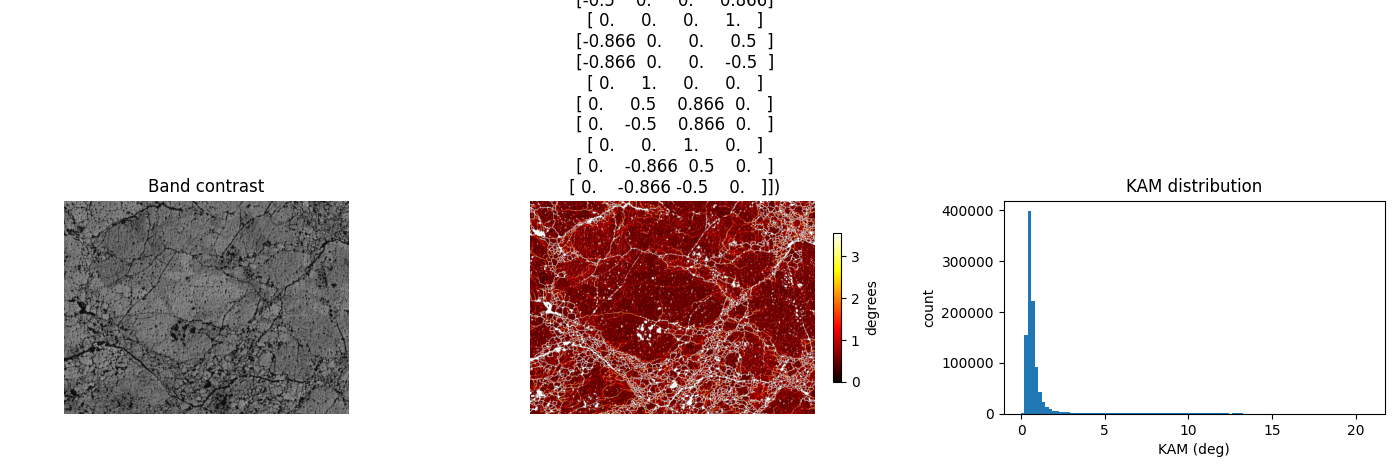

In [10]:
# ===== KAM via orix (symmetry-aware) =====

from orix.quaternion import Orientation
from orix.quaternion.symmetry import C1, C2, D2, D3, D6, C4, Oh

# ---------- USER PARAMETERS ----------
KAM_KERNEL = 1   # Kernel radius: 1 = 3x3, 2 = 5x5, 3 = 7x7, etc.
# --------------------------------------

LAUE_TO_ORIX = {
    '1': C1, '2': C2, '3': D2, '6': D3, '7': D6, '9': Oh, '11': C1,
}

def get_phase_symmetry(ebsd_data, phase_id=1):
    phases = ebsd_data['meta'].get('phases', {})
    if phase_id in phases:
        info = phases[phase_id]
        laue_str = str(info[3]).strip() if len(info) > 3 else '?'
        sym = LAUE_TO_ORIX.get(laue_str, None)
        name = info[2] if len(info) > 2 else f'phase_{phase_id}'
        print(f'  Phase {phase_id}: {name}, Laue={laue_str} -> {sym}')
        return sym
    return None


def compute_kam_orix(e1_deg, e2_deg, e3_deg, symmetry, mask=None,
                      kernel=1, degrees=True):
    """Compute KAM using orix Orientation.angle_with().

    kernel: neighborhood radius in pixels.
        1 = 3x3 (8 neighbors), 2 = 5x5 (24 neighbors), etc.
        Matches MTEX/OIM convention.
    """
    ny, nx = e1_deg.shape
    euler_rad = np.deg2rad(np.stack([e1_deg, e2_deg, e3_deg], axis=-1)).astype(np.float64)

    ori = Orientation.from_euler(euler_rad.reshape(-1, 3), symmetry=symmetry)
    ori = ori.reshape(ny, nx)

    kam = np.zeros((ny, nx), dtype=np.float64)
    count = np.zeros((ny, nx), dtype=np.float64)

    if mask is None:
        mask = np.ones((ny, nx), dtype=bool)

    # Generate all (dy, dx) offsets within the kernel radius
    offsets = []
    for dy in range(-kernel, kernel + 1):
        for dx in range(-kernel, kernel + 1):
            if dy == 0 and dx == 0:
                continue
            # Only count each pair once: (dy,dx) and (-dy,-dx) are the same pair
            if (dy, dx) > (0, 0) or (dy == 0 and dx > 0):
                offsets.append((dy, dx))

    print(f'  Kernel={kernel} -> {2*kernel+1}x{2*kernel+1}, {len(offsets)} unique neighbor pairs')

    for dy, dx in offsets:
        # Slice pairs so ori1[i,j] is compared with ori2[i,j] = ori1[i+dy, j+dx]
        if dy >= 0:
            sy1 = slice(None, ny - dy) if dy > 0 else slice(None)
            sy2 = slice(dy, None) if dy > 0 else slice(None)
        else:
            sy1 = slice(-dy, None)
            sy2 = slice(None, ny + dy)

        if dx >= 0:
            sx1 = slice(None, nx - dx) if dx > 0 else slice(None)
            sx2 = slice(dx, None) if dx > 0 else slice(None)
        else:
            sx1 = slice(-dx, None)
            sx2 = slice(None, nx + dx)

        o1 = ori[sy1, sx1]
        o2 = ori[sy2, sx2]
        m = mask[sy1, sx1] & mask[sy2, sx2]

        if not m.any():
            continue

        angles = np.full(o1.shape, np.nan)
        angles[m] = o1[m].angle_with(o2[m])
        v = np.isfinite(angles)
        a = np.where(v, angles, 0)

        kam[sy1, sx1] += a
        kam[sy2, sx2] += a
        count[sy1, sx1] += v
        count[sy2, sx2] += v

    kam = np.where(count > 0, kam / count, 0)
    kam[~mask] = np.nan
    if degrees:
        kam = np.rad2deg(kam)
    return kam


# --- Compute KAM for current dataset ---
phase_map = ebsd['phase']
unique_phases, phase_counts = np.unique(phase_map, return_counts=True)
dominant_phase = unique_phases[np.argmax(phase_counts)]
print(f'Phases: {dict(zip(unique_phases, phase_counts))}')
print(f'Dominant phase: {dominant_phase}')

sym = get_phase_symmetry(ebsd, phase_id=dominant_phase)
if sym is None:
    for pid in unique_phases:
        sym = get_phase_symmetry(ebsd, phase_id=int(pid))
        if sym is not None:
            dominant_phase = int(pid)
            break
if sym is None:
    print('WARNING: could not determine symmetry, using C1')
    sym = C1

phase_mask = (phase_map == dominant_phase)
print(f'Phase mask: {phase_mask.sum()}/{phase_mask.size} ({phase_mask.mean():.1%})')

print(f'Computing KAM (kernel={KAM_KERNEL})...')
kam = compute_kam_orix(ebsd['euler1'], ebsd['euler2'], ebsd['euler3'],
                        symmetry=sym, mask=phase_mask,
                        kernel=KAM_KERNEL, degrees=True)
print(f'KAM: [{np.nanmin(kam):.4f}, {np.nanmax(kam):.4f}] deg, median={np.nanmedian(kam):.4f}')

ny, nx = kam.shape
aspect = ny / nx
fig_w = 14
fig_h = max(4, fig_w * aspect * 0.45)

fig, axes = plt.subplots(1, 3, figsize=(fig_w, fig_h))
axes[0].imshow(ebsd['bc'], cmap='gray', aspect='equal')
axes[0].set_title('Band contrast')
im = axes[1].imshow(kam, cmap='hot', vmin=0, vmax=np.nanpercentile(kam, 95), aspect='equal')
axes[1].set_title(f'KAM (kernel={KAM_KERNEL}, {sym})')
plt.colorbar(im, ax=axes[1], label='degrees', shrink=0.7)
axes[2].hist(kam[np.isfinite(kam)].ravel(), bins=100,
             range=(0, np.nanpercentile(kam, 99)))
axes[2].set(xlabel='KAM (deg)', ylabel='count', title='KAM distribution')
for ax in axes[:2]: ax.axis('off')
plt.tight_layout()
plt.show()

Computing per-phase log-orientation fields...
  Phase 1: Quartz-new, Laue=7 -> Symmetry (12,) 622
[[ 1.     0.     0.     0.   ]
 [ 0.5    0.     0.     0.866]
 [-0.5    0.     0.     0.866]
 [ 0.     0.     0.     1.   ]
 [-0.866  0.     0.     0.5  ]
 [-0.866  0.     0.    -0.5  ]
 [ 0.     1.     0.     0.   ]
 [ 0.     0.5    0.866  0.   ]
 [ 0.    -0.5    0.866  0.   ]
 [ 0.     0.     1.     0.   ]
 [ 0.    -0.866  0.5    0.   ]
 [ 0.    -0.866 -0.5    0.   ]]
  Phase 1 (Quartz-new, Symmetry (12,) 622
[[ 1.     0.     0.     0.   ]
 [ 0.5    0.     0.     0.866]
 [-0.5    0.     0.     0.866]
 [ 0.     0.     0.     1.   ]
 [-0.866  0.     0.     0.5  ]
 [-0.866  0.     0.    -0.5  ]
 [ 0.     1.     0.     0.   ]
 [ 0.     0.5    0.866  0.   ]
 [ 0.    -0.5    0.866  0.   ]
 [ 0.     0.     1.     0.   ]
 [ 0.    -0.866  0.5    0.   ]
 [ 0.    -0.866 -0.5    0.   ]]): 1030618 px, theta med=46.12 p99=79.23 deg


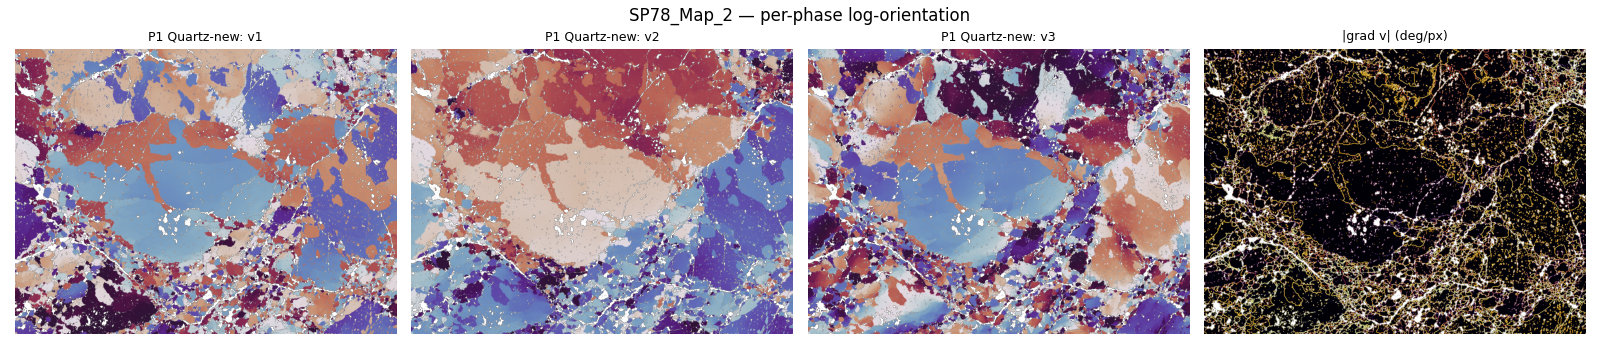

In [11]:
# ===== Per-phase log-orientation field via orix =====

def compute_log_orientation_per_phase(ebsd_data):
    """Compute log-orientation field separately for each phase.
    
    Returns dict: phase_id -> {
        'log_field': (ny, nx, 3) float32,
        'mask': (ny, nx) bool,
        'q_ref': (4,) quaternion,
        'symmetry': orix symmetry object,
        'name': str,
        'stats': dict,
    }
    """
    e1 = ebsd_data['euler1'].astype(np.float64)
    e2 = ebsd_data['euler2'].astype(np.float64)
    e3 = ebsd_data['euler3'].astype(np.float64)
    phase_map = ebsd_data['phase']
    meta = ebsd_data['meta']
    ny, nx = e1.shape

    phase_ids = [int(p) for p in np.unique(phase_map) if int(p) > 0]
    results = {}

    for pid in phase_ids:
        mask = (phase_map == pid)
        n_pix = mask.sum()
        if n_pix < 10:
            continue

        # Get symmetry from metadata
        sym = get_phase_symmetry(ebsd_data, phase_id=pid)
        if sym is None:
            sym = C1
        pname = meta.get('phases', {}).get(pid, ['?','?','?'])[2] if pid in meta.get('phases', {}) else f'phase_{pid}'

        # Build orientations for this phase only
        euler_rad = np.deg2rad(np.stack([e1[mask], e2[mask], e3[mask]], axis=1))
        ori = Orientation.from_euler(euler_rad, symmetry=sym)

        # Karcher mean (symmetry-aware) via orix
        # Use orientation tensor dominant eigenvector as reference
        q_all = ori.data.copy()
        q_all *= np.where(q_all[:, 0:1] >= 0, 1.0, -1.0)
        T = (q_all.T @ q_all) / n_pix
        _, eigvecs = np.linalg.eigh(T)
        q_ref = eigvecs[:, -1]
        if q_ref[0] < 0:
            q_ref = -q_ref

        # Refine with symmetry-aware iteration
        sym_q = sym.data
        for _ in range(5):
            # For each pixel, find symmetry op minimizing angle to q_ref
            q_sym = _quat_mul(q_all[:, None, :], sym_q[None, :, :])  # (N, S, 4)
            rel = _quat_mul(_quat_conj(q_ref)[None, None, :], q_sym)
            rel *= np.where(rel[..., 0:1] >= 0, 1.0, -1.0)
            best = np.argmax(rel[..., 0], axis=1)
            q_aligned = q_sym[np.arange(n_pix), best]
            q_aligned *= np.where(q_aligned[:, 0:1] >= 0, 1.0, -1.0)
            T = (q_aligned.T @ q_aligned) / n_pix
            _, eigvecs = np.linalg.eigh(T)
            q_new = eigvecs[:, -1]
            if q_new[0] < 0:
                q_new = -q_new
            if abs(float(q_ref @ q_new)) > 0.9999:
                break
            q_ref = q_new

        # Compute log map: v = theta * axis where rel = q_ref^-1 * q_best
        rel_best = _quat_mul(_quat_conj(q_ref)[None, :], q_aligned)
        rel_best *= np.where(rel_best[:, 0:1] >= 0, 1.0, -1.0)
        w = np.clip(rel_best[:, 0], -1.0, 1.0)
        theta = 2.0 * np.arccos(w)
        sin_half = np.sqrt(np.maximum(1.0 - w * w, 0.0))
        small = sin_half < 1e-8
        safe = np.where(small, 1.0, sin_half)
        axis = rel_best[:, 1:4] / safe[:, None]
        axis[small] = 0.0
        omega = theta[:, None] * axis
        omega[small] = 2.0 * rel_best[small, 1:4]

        # Write into spatial field
        log_field = np.zeros((ny, nx, 3), dtype=np.float32)
        yy, xx = np.where(mask)
        log_field[yy, xx, :] = omega.astype(np.float32)

        stats = {
            'n_pixels': int(n_pix),
            'theta_median_deg': float(np.rad2deg(np.median(theta))),
            'theta_p99_deg': float(np.rad2deg(np.percentile(theta, 99))),
        }

        results[pid] = {
            'log_field': log_field,
            'mask': mask,
            'q_ref': q_ref,
            'symmetry': sym,
            'name': pname,
            'stats': stats,
        }
        print(f'  Phase {pid} ({pname}, {sym}): {n_pix} px, '
              f'theta med={stats["theta_median_deg"]:.2f} p99={stats["theta_p99_deg"]:.2f} deg')

    return results


def _quat_mul(a, b):
    aw, ax, ay, az = a[..., 0], a[..., 1], a[..., 2], a[..., 3]
    bw, bx, by, bz = b[..., 0], b[..., 1], b[..., 2], b[..., 3]
    return np.stack([
        aw*bw - ax*bx - ay*by - az*bz,
        aw*bx + ax*bw + ay*bz - az*by,
        aw*by - ax*bz + ay*bw + az*bx,
        aw*bz + ax*by - ay*bx + az*bw,
    ], axis=-1)

def _quat_conj(q):
    return np.stack([q[..., 0], -q[..., 1], -q[..., 2], -q[..., 3]], axis=-1)


# --- Run ---
print('Computing per-phase log-orientation fields...')
phase_log = compute_log_orientation_per_phase(ebsd)

# --- Visualize each phase ---
n_phases = len(phase_log)
if n_phases > 0:
    fig, axes = plt.subplots(n_phases, 4, figsize=(16, 3.5 * n_phases),
                              squeeze=False)
    for row, (pid, pdata) in enumerate(phase_log.items()):
        lf = pdata['log_field']
        mask = pdata['mask']
        for c in range(3):
            ax = axes[row, c]
            img = np.where(mask, lf[..., c], np.nan)
            vmax = np.nanpercentile(np.abs(img), 99)
            ax.imshow(img, cmap='twilight_shifted', vmin=-vmax, vmax=vmax, aspect='equal')
            ax.set_title(f'P{pid} {pdata["name"]}: v{c+1}', fontsize=9)
            ax.axis('off')
        # Gradient magnitude
        ax = axes[row, 3]
        dx_v = np.gradient(lf, axis=1)
        dy_v = np.gradient(lf, axis=0)
        grad_mag = np.rad2deg(np.sqrt(np.sum(dx_v**2 + dy_v**2, axis=-1)))
        grad_mag[~mask] = np.nan
        vmax_g = np.nanpercentile(grad_mag, 95)
        ax.imshow(grad_mag, cmap='inferno', vmin=0, vmax=vmax_g, aspect='equal')
        ax.set_title(f'|grad v| (deg/px)', fontsize=9)
        ax.axis('off')
    plt.suptitle(f'{meta["name"]} — per-phase log-orientation', fontsize=12)
    plt.tight_layout()
    plt.show()
else:
    print('No phases found with >10 pixels')

Computing per-phase Nye tensor...
  Phase 1: Quartz-new, Laue=7 -> Symmetry (12,) 622
[[ 1.     0.     0.     0.   ]
 [ 0.5    0.     0.     0.866]
 [-0.5    0.     0.     0.866]
 [ 0.     0.     0.     1.   ]
 [-0.866  0.     0.     0.5  ]
 [-0.866  0.     0.    -0.5  ]
 [ 0.     1.     0.     0.   ]
 [ 0.     0.5    0.866  0.   ]
 [ 0.    -0.5    0.866  0.   ]
 [ 0.     0.     1.     0.   ]
 [ 0.    -0.866  0.5    0.   ]
 [ 0.    -0.866 -0.5    0.   ]]
  Phase 1 (Quartz-new, Symmetry (12,) 622
[[ 1.     0.     0.     0.   ]
 [ 0.5    0.     0.     0.866]
 [-0.5    0.     0.     0.866]
 [ 0.     0.     0.     1.   ]
 [-0.866  0.     0.     0.5  ]
 [-0.866  0.     0.    -0.5  ]
 [ 0.     1.     0.     0.   ]
 [ 0.     0.5    0.866  0.   ]
 [ 0.    -0.5    0.866  0.   ]
 [ 0.     0.     1.     0.   ]
 [ 0.    -0.866  0.5    0.   ]
 [ 0.    -0.866 -0.5    0.   ]]): 1030618 px, pairs=986741+990674, max pair theta=93.66 deg
  Done in 2.0s


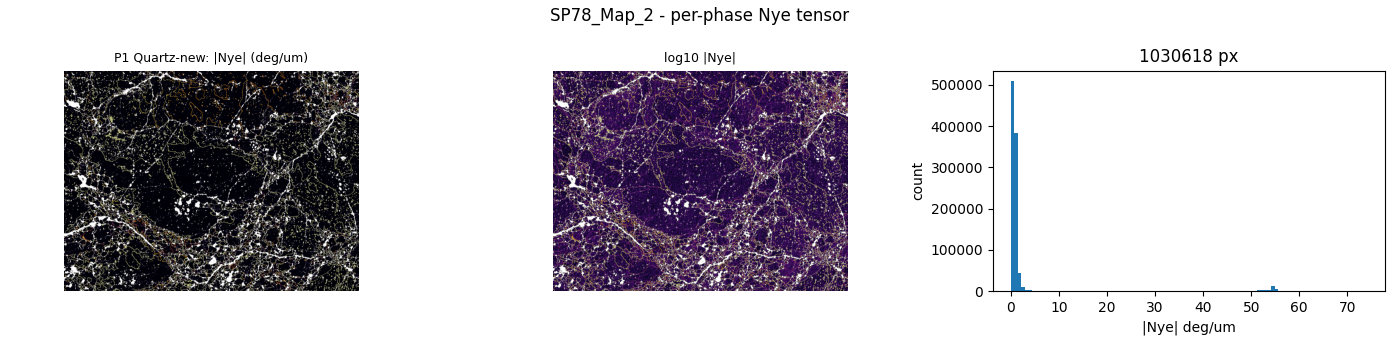

In [12]:
# ===== Per-phase pairwise Nye tensor =====
# For each pixel pair within the SAME phase, compute log of the local
# neighbor disorientation (not a global q_ref). This avoids the pi-boundary
# issue and gives the lattice curvature tensor directly.
#
# Returns dict: phase_id -> {
#   'nye': (ny, nx, 2, 3) — nye[y,x,0,:] = dv/dx, nye[y,x,1,:] = dv/dy  (rad/um)
#   'mask', 'name', 'symmetry', 'stats'
# }

def _nye_log_map(rel):
    """Axis-angle log map of unit quaternions."""
    w = np.clip(rel[..., 0], -1.0, 1.0)
    theta = 2.0 * np.arccos(w)
    sin_half = np.sqrt(np.maximum(1.0 - w * w, 0.0))
    small = sin_half < 1e-8
    safe = np.where(small, 1.0, sin_half)
    axis = rel[..., 1:4] / safe[..., None]
    omega = theta[..., None] * axis
    omega = np.where(small[..., None], 2.0 * rel[..., 1:4], omega)
    return omega


def _nye_sym_reduce(rel, sym_q):
    """Pick symmetry equivalent with largest w (smallest angle)."""
    rel_s = _quat_mul(rel[..., None, :], sym_q)  # (..., S, 4)
    rel_s *= np.where(rel_s[..., 0:1] >= 0, 1.0, -1.0)
    best = np.argmax(rel_s[..., 0], axis=-1)
    idx = np.expand_dims(best, -1)
    idx = np.broadcast_to(idx, (*idx.shape[:-1], 4))
    return np.take_along_axis(rel_s, idx[..., None, :], axis=-2).squeeze(-2)


def compute_nye_per_phase(ebsd_data):
    """Pairwise Nye tensor, computed per phase."""
    e1 = ebsd_data['euler1'].astype(np.float64)
    e2 = ebsd_data['euler2'].astype(np.float64)
    e3 = ebsd_data['euler3'].astype(np.float64)
    phase_map = ebsd_data['phase']
    m = ebsd_data['meta']
    xstep = float(m.get('xstep', 1.0))
    ystep = float(m.get('ystep', xstep))
    ny, nx = e1.shape

    # Euler -> quaternion (Bunge convention)
    euler_rad = np.deg2rad(np.stack([e1, e2, e3], axis=-1))
    ori_all = Orientation.from_euler(euler_rad.reshape(-1, 3), symmetry=C1)
    q_field = ori_all.data.reshape(ny, nx, 4).astype(np.float64)

    phase_ids = [int(p) for p in np.unique(phase_map) if int(p) > 0]
    results = {}

    for pid in phase_ids:
        mask = (phase_map == pid)
        n_pix = mask.sum()
        if n_pix < 10:
            continue

        sym = get_phase_symmetry(ebsd_data, phase_id=pid)
        if sym is None:
            sym = C1
        pname = m.get('phases', {}).get(pid, ['?','?','?'])[2] if pid in m.get('phases', {}) else f'phase_{pid}'
        sym_q = sym.data

        nye = np.zeros((ny, nx, 2, 3), dtype=np.float32)
        max_theta = 0.0
        n_pairs = [0, 0]

        for dir_idx, (dy, dx, step) in enumerate([(0, 1, xstep), (1, 0, ystep)]):
            ya = slice(0, ny - dy) if dy > 0 else slice(None)
            yb = slice(dy, None) if dy > 0 else slice(None)
            xa = slice(0, nx - dx) if dx > 0 else slice(None)
            xb = slice(dx, None) if dx > 0 else slice(None)

            same = mask[ya, xa] & mask[yb, xb]
            if not same.any():
                continue

            qa = q_field[ya, xa]
            qb = q_field[yb, xb]
            rel = _quat_mul(_quat_conj(qa), qb)
            rel_r = _nye_sym_reduce(rel, sym_q)
            omega = _nye_log_map(rel_r) / step

            nye[ya, xa, dir_idx, :] = np.where(
                same[..., None], omega.astype(np.float32), nye[ya, xa, dir_idx, :])

            w_cl = np.clip(rel_r[..., 0], -1, 1)
            theta = np.rad2deg(2 * np.arccos(w_cl))
            if same.any():
                max_theta = max(max_theta, float(theta[same].max()))
            n_pairs[dir_idx] = int(same.sum())

        # Zero out non-phase pixels
        nye[~mask] = 0

        results[pid] = {
            'nye': nye,
            'mask': mask,
            'name': pname,
            'symmetry': sym,
            'stats': {
                'n_pixels': int(n_pix),
                'n_pairs_x': n_pairs[0],
                'n_pairs_y': n_pairs[1],
                'max_pair_theta_deg': max_theta,
            },
        }
        print(f'  Phase {pid} ({pname}, {sym}): {n_pix} px, '
              f'pairs={n_pairs[0]}+{n_pairs[1]}, max pair theta={max_theta:.2f} deg')

    return results


# --- Run ---
import time as _t
_t0 = _t.time()
print('Computing per-phase Nye tensor...')
phase_nye = compute_nye_per_phase(ebsd)
print(f'  Done in {_t.time()-_t0:.1f}s')

# --- Visualize ---
n_ph = len(phase_nye)
if n_ph > 0:
    ny, nx = ebsd['euler1'].shape
    aspect = ny / nx
    fig_h = max(3.5, 14 * aspect * 0.3) * n_ph

    fig, axes = plt.subplots(n_ph, 3, figsize=(14, fig_h), squeeze=False)
    for row, (pid, pdata) in enumerate(phase_nye.items()):
        nye = pdata['nye']
        mask = pdata['mask']
        frob = np.sqrt(np.sum(nye ** 2, axis=(-1, -2)))
        frob_deg = np.rad2deg(frob)
        frob_deg[~mask] = np.nan

        ax = axes[row, 0]
        vmax = np.nanpercentile(frob_deg, 95)
        ax.imshow(frob_deg, cmap='inferno', vmin=0, vmax=vmax, aspect='equal')
        ax.set_title(f'P{pid} {pdata["name"]}: |Nye| (deg/um)', fontsize=9)
        ax.axis('off')

        ax = axes[row, 1]
        log_frob = np.log10(frob_deg + 1e-3)
        log_frob[~mask] = np.nan
        vmin_l = np.nanpercentile(log_frob, 5)
        vmax_l = np.nanpercentile(log_frob, 99)
        ax.imshow(log_frob, cmap='inferno', vmin=vmin_l, vmax=vmax_l, aspect='equal')
        ax.set_title(f'log10 |Nye|', fontsize=9)
        ax.axis('off')

        ax = axes[row, 2]
        vals = frob_deg[mask & np.isfinite(frob_deg)]
        ax.hist(vals, bins=100, range=(0, np.percentile(vals, 99)))
        ax.set(xlabel='|Nye| deg/um', ylabel='count',
               title=f'{pdata["stats"]["n_pixels"]} px')

    plt.suptitle(f'{meta["name"]} - per-phase Nye tensor', fontsize=12)
    plt.tight_layout()
    plt.show()

Per-phase GND density from Nye tensor:

  Phase 1 (Quartz-new): b=0.49 nm, median rho=2.66e+13 m-2, p99=2.64e+15 m-2


/var/folders/k8/wqqjlxf115z79hdp7q2t162c0000gn/T/ipykernel_27984/2044861501.py:115: RuntimeWarning: divide by zero encountered in log2
  ax.imshow(np.log2(ratio), cmap='RdBu_r', vmin=-3, vmax=3, aspect='equal')


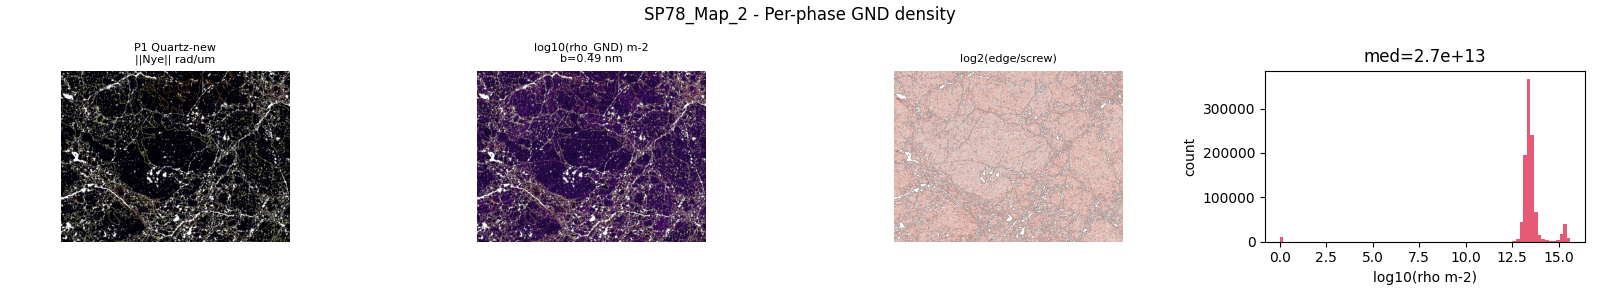

In [13]:
# --- Per-phase GND density from Nye tensor ---

# Burgers vector magnitudes (nm) for common rock-forming minerals
BURGERS_VECTORS = {
    # Olivine / orthorhombic
    'Forsterite':    0.50,  # [100] a-slip
    'Olivine':       0.50,
    'Orthopyroxene': 0.52,
    'Enstatite':     0.52,
    # Quartz
    'Quartz':        0.49,  # <a> slip
    'Quartz-new':    0.49,
    'Quartz Alpha':  0.49,
    # Feldspars
    'Orthoclase':    0.65,  # ~a/2 [110]
    'Sanidine':      0.65,
    'K-Feldspar':    0.65,
    'Microcline':    0.65,
    'Albite':        0.81,  # [010] b-slip
    'Plagioclase':   0.81,
    'Anorthite':     0.81,  # [010] or [001], ~8.1 A
    # Micas
    'Biotite':       0.53,  # <a> basal slip, a ~ 5.3 A
    'Muscovite':     0.52,  # <a> basal slip, a ~ 5.2 A
    'Phlogopite':    0.53,
    # Carbonates
    'Calcite':       0.50,  # <a> e-twin / r-slip
    'Dolomite':      0.48,
    # Cubic
    'Chromite':      0.59,  # spinel a/2 <110>
    'Spinel':        0.57,
    # Pyroxenes / amphiboles
    'Diopside':      0.52,
    'Augite':        0.52,
    'Hornblende':    0.54,
    'Tremolite':     0.53,
}

def _get_burgers(pname):
    """Look up Burgers vector, fuzzy match on name."""
    if pname in BURGERS_VECTORS:
        return BURGERS_VECTORS[pname]
    pl = pname.lower()
    for k, v in BURGERS_VECTORS.items():
        if k.lower() in pl or pl in k.lower():
            return v
    return 0.50  # default

# --- Compute per-phase GND ---
print('Per-phase GND density from Nye tensor:\n')

phase_gnd = {}
for pid, pdata in phase_nye.items():
    nye = pdata['nye']         # (ny, nx, 2, 3) rad/um
    mask = pdata['mask']
    pname = pdata['name']
    b_nm = _get_burgers(pname)
    b_um = b_nm * 1e-3         # nm -> um

    # Frobenius norm of Nye tensor
    frob = np.sqrt(np.sum(nye ** 2, axis=(-1, -2)))  # rad/um
    frob[~mask] = np.nan

    # GND density: rho = ||alpha|| / b  (1/um^2) -> * 1e12 for m^-2
    rho = frob / b_um          # 1/um^2
    rho_m2 = rho * 1e12        # m^-2

    # Edge vs screw (sample frame)
    screw = np.sqrt(nye[:,:,0,0]**2 + nye[:,:,1,1]**2)
    edge = np.sqrt(nye[:,:,0,1]**2 + nye[:,:,0,2]**2 +
                   nye[:,:,1,0]**2 + nye[:,:,1,2]**2)
    screw[~mask] = np.nan
    edge[~mask] = np.nan

    vals = rho_m2[mask & np.isfinite(rho_m2)]
    phase_gnd[pid] = {
        'frob': frob, 'rho_m2': rho_m2,
        'screw': screw, 'edge': edge,
        'mask': mask, 'name': pname, 'b_nm': b_nm,
    }
    print(f'  Phase {pid} ({pname}): b={b_nm:.2f} nm, '
          f'median rho={np.median(vals):.2e} m-2, '
          f'p99={np.percentile(vals, 99):.2e} m-2')

# --- Visualize ---
n_ph = len(phase_gnd)
ny, nx = ebsd['euler1'].shape
aspect = ny / nx
fig_h = max(3, 12 * aspect * 0.3) * n_ph

fig, axes = plt.subplots(n_ph, 4, figsize=(16, fig_h), squeeze=False)
for row, (pid, gdata) in enumerate(phase_gnd.items()):
    mask = gdata['mask']

    # |Nye| Frobenius
    ax = axes[row, 0]
    v = gdata['frob'].copy(); v[~mask] = np.nan
    vmax = np.nanpercentile(v, 95)
    ax.imshow(v, cmap='inferno', vmin=0, vmax=vmax, aspect='equal')
    ax.set_title(f'P{pid} {gdata["name"]}\n||Nye|| rad/um', fontsize=8)
    ax.axis('off')

    # rho GND (m^-2) log scale
    ax = axes[row, 1]
    v = np.log10(gdata['rho_m2'] + 1); v[~mask] = np.nan
    vmin_l = np.nanpercentile(v, 5); vmax_l = np.nanpercentile(v, 99)
    ax.imshow(v, cmap='inferno', vmin=vmin_l, vmax=vmax_l, aspect='equal')
    ax.set_title(f'log10(rho_GND) m-2\nb={gdata["b_nm"]:.2f} nm', fontsize=8)
    ax.axis('off')

    # Edge vs screw
    ax = axes[row, 2]
    ratio = gdata['edge'] / np.maximum(gdata['screw'], 1e-10)
    ratio[~mask] = np.nan
    ax.imshow(np.log2(ratio), cmap='RdBu_r', vmin=-3, vmax=3, aspect='equal')
    ax.set_title('log2(edge/screw)', fontsize=8)
    ax.axis('off')

    # Histogram
    ax = axes[row, 3]
    vals = gdata['rho_m2'][mask & np.isfinite(gdata['rho_m2'])]
    ax.hist(np.log10(vals + 1), bins=80, color='crimson', alpha=0.7)
    ax.set(xlabel='log10(rho m-2)', ylabel='count',
           title=f'med={np.median(vals):.1e}')

plt.suptitle(f'{meta["name"]} - Per-phase GND density', fontsize=12)
plt.tight_layout()
plt.show()

In [15]:
# ===== Wavelet scalebar helper =====
import matplotlib.patheffects as path_effects

def _wavelet_shape(wavelet='gaussian', n_pts=301):
    """Unit-scale analyzing wavelet profile in direct space.
    Returns (x, psi) normalized to peak=1, x in units of sigma_W."""
    x = np.linspace(-4, 4, n_pts)
    if wavelet == 'mexican':
        # psi = d/dx[(2-x^2)exp(-x^2/2)] = x(x^2-3)exp(-x^2/2)
        psi = x * (x**2 - 3) * np.exp(-x**2 / 2)
    else:
        # psi = -x exp(-x^2/2)
        psi = -x * np.exp(-x**2 / 2)
    psi /= np.max(np.abs(psi))
    return x, psi


def add_wavelet_scalebar(ax, scale, px_to_unit=1.0, unit_str='px',
                          wavelet='gaussian', loc='lower right',
                          height_frac=0.14, pad_frac=0.02, fontsize=8,
                          color='#39FF14'):
    """Draw analyzing wavelet shape + bar. Bar length = scale in physical units."""
    x_unit, psi = _wavelet_shape(wavelet)

    # Bar length = scale parameter in physical units
    bar_px = scale
    label_val = bar_px * px_to_unit

    imgs = ax.get_images()
    img_nx = int(imgs[0].get_array().shape[1]) if imgs else 512
    bar_frac = bar_px / img_nx
    bar_frac = min(bar_frac, 0.45)

    # Wavelet drawn proportional to bar (x_unit range [-4,4] maps to 8 sigma_W)
    wave_frac = bar_frac * (x_unit[-1] - x_unit[0]) / 2  # /2 because bar = ~2 sigma
    wave_frac = min(wave_frac, 0.50)

    loc_table = {
        'lower right': (1 - pad_frac, pad_frac),
        'lower left':  (pad_frac, pad_frac),
        'upper right': (1 - pad_frac, 1 - pad_frac - height_frac),
        'upper left':  (pad_frac, 1 - pad_frac - height_frac),
    }
    anchor_x, by = loc_table.get(loc, loc_table['lower right'])

    # Position: bar centered, wavelet centered on bar
    if 'right' in loc:
        bar_x1 = anchor_x
        bar_x0 = bar_x1 - bar_frac
    else:
        bar_x0 = anchor_x
        bar_x1 = bar_x0 + bar_frac
    bar_cx = 0.5 * (bar_x0 + bar_x1)

    # Map wavelet x coordinates to axes fraction
    # x_unit is in sigma_W units; bar spans ~1 sigma_W (the scale param)
    # so the wavelet extends beyond the bar (showing tails)
    def x_to_ax(xv):
        return bar_cx + xv / 2.0 * bar_frac  # x=±1 maps to bar ends

    bar_y = by + 0.10 * height_frac
    wave_cy = by + 0.58 * height_frac
    wave_amp = 0.35 * height_frac
    label_y = by + 0.01 * height_frac

    fx_c = [path_effects.withStroke(linewidth=2.5, foreground='black')]
    fx_t = [path_effects.withStroke(linewidth=2.0, foreground='black')]

    # Clip wavelet to axes bounds [0,1]
    wave_x = np.array([x_to_ax(xv) for xv in x_unit])
    wave_y = np.array([wave_cy + p * wave_amp for p in psi])
    clip = (wave_x >= -0.02) & (wave_x <= 1.02)
    if clip.any():
        ax.plot(wave_x[clip], wave_y[clip], color=color, lw=1.4,
                transform=ax.transAxes, zorder=11, clip_on=False,
                path_effects=fx_c, solid_capstyle='round')



    # Label
    if label_val >= 100:
        lbl = f'{label_val:.0f} {unit_str}'
    elif label_val >= 10:
        lbl = f'{label_val:.1f} {unit_str}'
    else:
        lbl = f'{label_val:.2f} {unit_str}'
    ax.text(bar_cx, label_y, lbl,
            ha='center', va='bottom', fontsize=fontsize, color=color,
            fontweight='bold', transform=ax.transAxes, zorder=13,
            clip_on=False, path_effects=fx_t)

print('add_wavelet_scalebar defined (shape + scale bar)')

add_wavelet_scalebar defined (shape + scale bar)


Field: log_orientation, Wavelet: gaussian, Chain: anchor
Scales: 88, range [13.0, 3124.2] px

=== Phase 1: Quartz-new (1030618 px) ===
  CWT...
  Tensor SVD...
  WTMM (anchor)...
  7919 chains, h med=-0.695

1 phases computed.


Dropdown(description='Phase:', layout=Layout(width='420px'), options=(('P1: Quartz-new (7919 ch)', 1),), style…

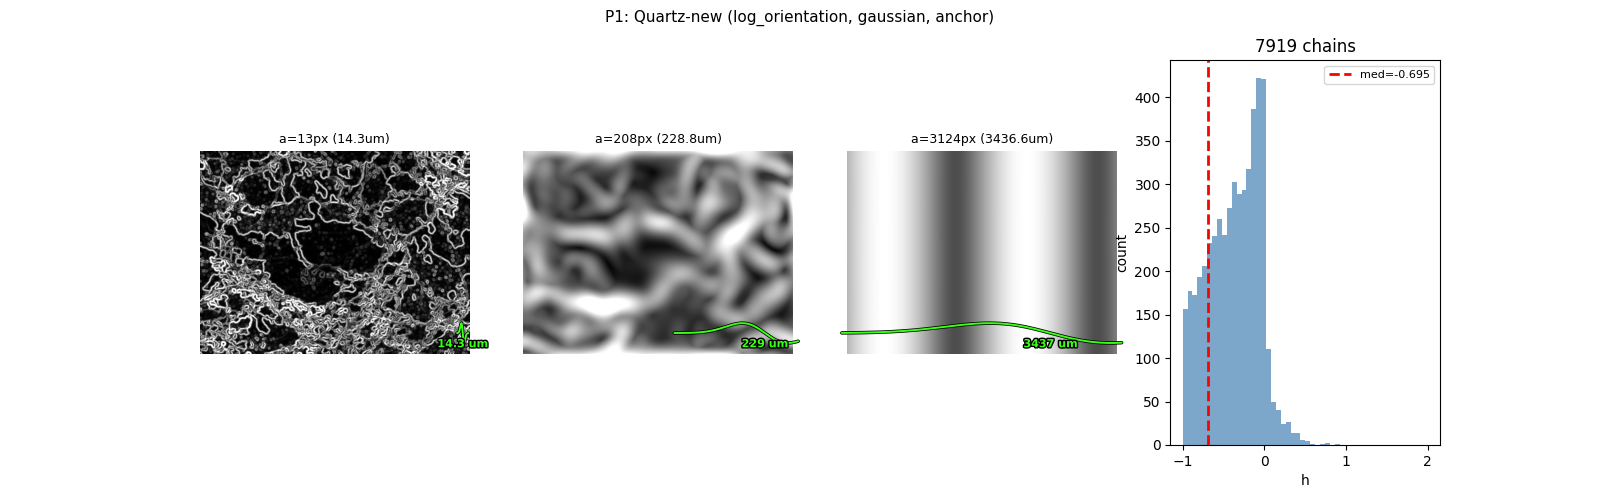

In [16]:
# ===== Per-phase tensor SVD WTMM =====

# ---------- USER PARAMETERS ----------
FIELD_SOURCE = 'log_orientation'  # 'log_orientation' or 'nye'
WAVELET = 'gaussian'              # 'gaussian' or 'mexican'
CHAIN_METHOD = 'anchor'           # 'greedy' (xsmurf default) or 'anchor'
N_OCT = 8
N_VOX = 11
A_MIN = 1.863
PAD = 32
BORDER_PCT = 1.5
THRESH = 1e-3
SIMILITUDE = 0.8
DIST_FRAC = 0.3
# --------------------------------------

from xsmurf_wrapper.anchor_chain import chain_and_extract

scales = compute_scales(N_OCT, N_VOX, A_MIN)
px_um = float(meta.get('xstep', 1.0))
print(f'Field: {FIELD_SOURCE}, Wavelet: {WAVELET}, Chain: {CHAIN_METHOD}')
print(f'Scales: {len(scales)}, range [{scales[0]:.1f}, {scales[-1]:.1f}] px')

if FIELD_SOURCE == 'log_orientation':
    source = phase_log
elif FIELD_SOURCE == 'nye':
    source = phase_nye
else:
    raise ValueError(f'Unknown FIELD_SOURCE: {FIELD_SOURCE}')

# --- Compute per-phase ---
phase_wtmm = {}

for pid, pdata in source.items():
    mask = pdata['mask']
    pname = pdata['name']
    n_pix = mask.sum()
    if n_pix < 100:
        print(f'  Skip phase {pid} ({pname}): {n_pix} px')
        continue

    print(f'\n=== Phase {pid}: {pname} ({n_pix} px) ===')

    if FIELD_SOURCE == 'log_orientation':
        lf = pdata['log_field']
        fields = [np.where(mask, lf[..., c], 0).astype(np.float32) for c in range(3)]
    else:
        nye = pdata['nye']
        fields = [np.where(mask, nye[..., 0, c], 0).astype(np.float32) for c in range(3)]

    print(f'  CWT...')
    derivs = [cwt_2d_f32(f, scales, pad=PAD, derivs='first', wavelet=WAVELET, verbose=False)
              for f in fields]

    print(f'  Tensor SVD...')
    ny, nx = fields[0].shape
    n_sc = len(scales)
    mod_all = np.zeros((n_sc, ny, nx), dtype=np.float32)
    arg_all = np.zeros((n_sc, ny, nx), dtype=np.float32)
    for si in range(n_sc):
        smax, smin, arg = tensor_svd_3x2(
            derivs[0]['dx'][si], derivs[0]['dy'][si],
            derivs[1]['dx'][si], derivs[1]['dy'][si],
            derivs[2]['dx'][si], derivs[2]['dy'][si])
        mod_all[si] = smax
        arg_all[si] = arg

    print(f'  WTMM ({CHAIN_METHOD})...')
    ext_images = []
    for si, scale in enumerate(scales):
        dx_svd = (mod_all[si] * np.cos(arg_all[si])).astype(np.float32)
        dy_svd = (mod_all[si] * np.sin(arg_all[si])).astype(np.float32)
        ext, _, _ = xsm.wtmm2d(
            xsm.XImage.from_numpy(dx_svd),
            xsm.XImage.from_numpy(dy_svd), scale, thresh=THRESH)
        ext_images.append(ext)

    chains = chain_and_extract(
        ext_images, scales, method=CHAIN_METHOD,
        a_min=A_MIN, n_oct=N_OCT, n_vox=N_VOX,
        similitude=SIMILITUDE, smooth=False,
        border_percent=BORDER_PCT, dist_frac=DIST_FRAC)
    holders = xsm.compute_holder_exponents(chains)

    phase_wtmm[pid] = {
        'mod': mod_all, 'arg': arg_all,
        'chains': chains, 'holders': holders,
        'name': pname, 'mask': mask,
    }
    h = [h['h'] for h in holders]
    if h:
        print(f'  {len(chains)} chains, h med={np.median(h):.3f}')

print(f'\n{len(phase_wtmm)} phases computed.')

# --- Interactive dropdown viewer ---
show_idx = [0, len(scales)//2, len(scales)-1]

phase_dd = widgets.Dropdown(
    options=[(f'P{pid}: {w["name"]} ({len(w["chains"])} ch)', pid)
             for pid, w in phase_wtmm.items()],
    description='Phase:', style={'description_width': 'initial'},
    layout=widgets.Layout(width='420px'))

ny_img, nx_img = ebsd['euler1'].shape
aspect = ny_img / nx_img
fig_w = 16
fig_h = max(5, fig_w * aspect * 0.28)

_fig_wt, _axes_wt = plt.subplots(1, len(show_idx) + 1,
                                   figsize=(fig_w, fig_h))

def _draw_wt(change=None):
    pid = phase_dd.value
    w = phase_wtmm[pid]
    #mask = w['mask']

    for ax in _axes_wt:
        ax.cla()

    for col, si in enumerate(show_idx):
        ax = _axes_wt[col]
        m = w['mod'][si].copy()
        #m[~mask] = np.nan
        vmax = np.nanpercentile(m, 98)
        ax.imshow(m, cmap='binary_r', vmin=0, vmax=vmax, aspect='equal')
        ax.set_title(f'a={scales[si]:.0f}px ({scales[si]*px_um:.1f}um)', fontsize=9)
        ax.axis('off')
        add_wavelet_scalebar(ax, scale=scales[si], px_to_unit=px_um,
                              unit_str='um', wavelet=WAVELET)

    ax = _axes_wt[-1]
    h = [h['h'] for h in w['holders']]
    if h:
        ax.hist(h, bins=50, range=(-1, 2), alpha=0.7, color='steelblue')
        ax.axvline(np.median(h), color='red', ls='--', lw=2,
                   label=f'med={np.median(h):.3f}')
        ax.legend(fontsize=8)
    ax.set(xlabel='h', ylabel='count', title=f'{len(w["chains"])} chains')

    _fig_wt.suptitle(
        f'P{pid}: {w["name"]} ({FIELD_SOURCE}, {WAVELET}, {CHAIN_METHOD})',
        fontsize=11)
    _fig_wt.canvas.draw_idle()

phase_dd.observe(_draw_wt, names='value')
display(phase_dd)
_draw_wt()

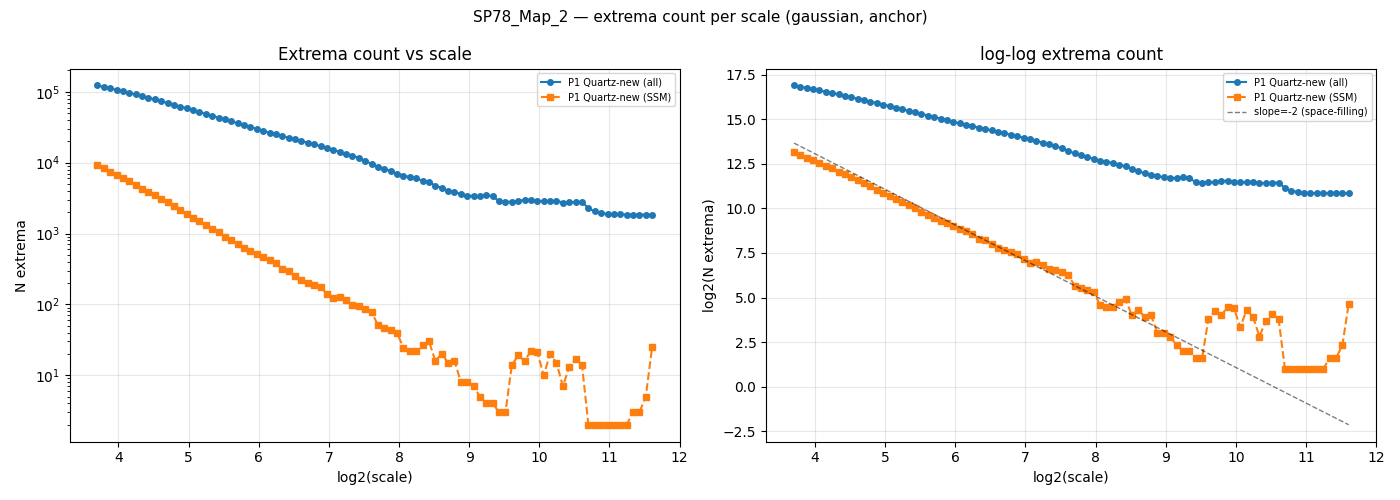


   Scale  log2(a)   P1 all  P1 SSM
------------------------------------


In [17]:
# ===== Log-log extrema count per scale per phase =====
# Re-compute extrema (lightweight — no chaining needed) to count per scale

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for pid, wdata in phase_wtmm.items():
    mask = wdata['mask']
    pname = wdata['name']
    n_sc = len(scales)

    # Count extrema at each scale from the stored modulus
    all_counts = []
    ssm_counts = []
    for si, scale in enumerate(scales):
        dx_svd = (wdata['mod'][si] * np.cos(wdata['arg'][si])).astype(np.float32)
        dy_svd = (wdata['mod'][si] * np.sin(wdata['arg'][si])).astype(np.float32)
        ext, _, _ = xsm.wtmm2d(
            xsm.XImage.from_numpy(dx_svd),
            xsm.XImage.from_numpy(dy_svd), scale, thresh=THRESH)
        ext = xsm.cut_edge(ext, border_percent=BORDER_PCT)
        n_all = len(ext.get_extrema_arrays()['x'])
        xsm.hsearch(ext)
        xsm.ssm(ext)
        n_ssm = len(ext.get_single_maxima_arrays()['x'])
        all_counts.append(n_all)
        ssm_counts.append(n_ssm)

    log2_s = np.log2(scales)

    # Left: log-log (extrema count vs scale)
    ax = axes[0]
    ax.semilogy(log2_s, all_counts, 'o-', ms=4, lw=1.5, label=f'P{pid} {pname} (all)')
    ax.semilogy(log2_s, ssm_counts, 's--', ms=4, lw=1.5, label=f'P{pid} {pname} (SSM)')

    # Right: log2 count vs log2 scale
    ax = axes[1]
    ax.plot(log2_s, np.log2(np.maximum(all_counts, 1)), 'o-', ms=4, lw=1.5,
            label=f'P{pid} {pname} (all)')
    ax.plot(log2_s, np.log2(np.maximum(ssm_counts, 1)), 's--', ms=4, lw=1.5,
            label=f'P{pid} {pname} (SSM)')

axes[0].set(xlabel='log2(scale)', ylabel='N extrema', title='Extrema count vs scale')
axes[0].legend(fontsize=7)
axes[0].grid(True, alpha=0.3)

axes[1].set(xlabel='log2(scale)', ylabel='log2(N extrema)', title='log-log extrema count')
axes[1].legend(fontsize=7)
axes[1].grid(True, alpha=0.3)

# Reference: N ~ a^{-d} where d=2 for space-filling
ax = axes[1]
log2_s_arr = np.array(log2_s)
ref_slope = -2
mid = len(log2_s_arr) // 2
ref_offset = np.log2(max(ssm_counts[mid], 1)) - ref_slope * log2_s_arr[mid]
ax.plot(log2_s_arr, ref_slope * log2_s_arr + ref_offset, 'k--', lw=1, alpha=0.5,
        label=f'slope=-2 (space-filling)')
ax.legend(fontsize=7)

plt.suptitle(f'{meta["name"]} — extrema count per scale ({WAVELET}, {CHAIN_METHOD})', fontsize=11)
plt.tight_layout()
plt.show()

# Print table
print(f'\n{"Scale":>8} {"log2(a)":>8} ', end='')
for pid in phase_wtmm:
    print(f'  P{pid} all  P{pid} SSM', end='')
print()
print('-' * (20 + 16 * len(phase_wtmm)))

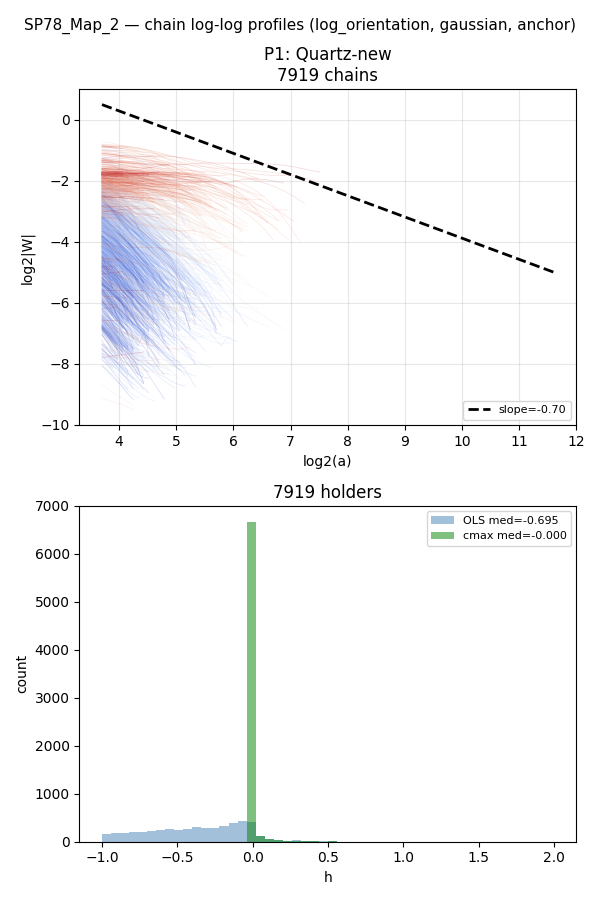


Phase                      Chains  Med len    Med h
----------------------------------------------------
P1 Quartz-new                7919        7   -0.695


In [18]:
# ===== Per-phase log-log chain profiles =====

def compute_holder_chainmax(chains):
    """Holder exponents using running max modulus along each chain."""
    results = []
    for ch in chains:
        mod = np.abs(ch['mod']).astype(np.float64)
        log2_s = ch['log2_scales']
        if len(mod) < 3:
            continue
        running_max = np.maximum.accumulate(mod)
        running_max[running_max == 0] = 1e-30
        log2_cmax = np.log2(running_max)
        A = np.vstack([log2_s, np.ones(len(log2_s))]).T
        res = np.linalg.lstsq(A, log2_cmax, rcond=None)
        h = res[0][0]
        results.append({'h': h, 'x': int(ch['x'][0]), 'y': int(ch['y'][0])})
    return results


n_ph = len(phase_wtmm)
fig, axes = plt.subplots(2, n_ph, figsize=(6 * n_ph, 9), squeeze=False)
log2_s = np.log2(scales)

for col, (pid, wdata) in enumerate(phase_wtmm.items()):
    chains = wdata['chains']
    holders = wdata['holders']
    h_lookup = {(int(h['x']), int(h['y'])): h['h'] for h in holders}
    h_vals = [h['h'] for h in holders]

    # Top: log-log chains colored by h
    ax = axes[0, col]
    if h_vals:
        vmin, vmax = np.percentile(h_vals, [5, 95])
        cm = plt.cm.coolwarm
        nm = plt.Normalize(vmin, vmax)
        for ch in chains[:2000]:
            n = len(ch['mod'])
            if n < 3:
                continue
            anchor = (int(ch['x'][0]), int(ch['y'][0]))
            h = h_lookup.get(anchor, np.nan)
            if not np.isfinite(h):
                continue
            ax.plot(ch['log2_scales'], ch['log2_mod'], '-',
                    color=cm(nm(h)), alpha=0.2, lw=0.5)
        mid = len(log2_s) // 2
        mods_mid = [ch['log2_mod'][min(mid, len(ch['mod'])-1)]
                    for ch in chains if len(ch['mod']) > mid]
        if mods_mid:
            h_med = np.median(h_vals)
            ref = h_med * (log2_s - log2_s[mid]) + np.median(mods_mid)
            ax.plot(log2_s, ref, 'k--', lw=2, label=f'slope={h_med:.2f}')
            ax.legend(fontsize=8, loc='lower right')
    ax.set(xlabel='log2(a)', ylabel='log2|W|',
           title=f'P{pid}: {wdata["name"]}\n{len(chains)} chains')
    ax.grid(True, alpha=0.3)

    # Bottom: h histograms (OLS + chainmax)
    ax = axes[1, col]
    h_cmax = [h['h'] for h in compute_holder_chainmax(chains)]
    if h_vals:
        ax.hist(h_vals, bins=50, range=(-1, 2), alpha=0.5,
                label=f'OLS med={np.median(h_vals):.3f}', color='steelblue')
    if h_cmax:
        ax.hist(h_cmax, bins=50, range=(-1, 2), alpha=0.5,
                label=f'cmax med={np.median(h_cmax):.3f}', color='green')
    ax.set(xlabel='h', ylabel='count', title=f'{len(holders)} holders')
    ax.legend(fontsize=8)

plt.suptitle(f'{meta["name"]} — chain log-log profiles ({FIELD_SOURCE}, {WAVELET}, {CHAIN_METHOD})',
             fontsize=11)
plt.tight_layout()
plt.show()

# Chain length stats
print(f'\n{"Phase":<25} {"Chains":>7} {"Med len":>8} {"Med h":>8}')
print('-' * 52)
for pid, wdata in phase_wtmm.items():
    chains = wdata['chains']
    h_vals = [h['h'] for h in wdata['holders']]
    lens = [len(ch['mod']) for ch in chains]
    if h_vals and lens:
        print(f'P{pid} {wdata["name"]:<22} {len(chains):>7d} {np.median(lens):>8.0f} {np.median(h_vals):>8.3f}')

In [22]:
# ===== Per-phase tensor SVD WTMM =====

# ---------- USER PARAMETERS ----------
FIELD_SOURCE = 'nye'  # 'log_orientation' or 'nye'
WAVELET = 'gaussian'              # 'gaussian' or 'mexican'
CHAIN_METHOD = 'greedy'           # 'greedy' (xsmurf default) or 'anchor'
N_OCT = 4
N_VOX = 11
A_MIN = 1
PAD = 32
BORDER_PCT = 1.5
THRESH = 1e-3
SIMILITUDE = 0.8
DIST_FRAC = 0.3
FRACINT_ALPHA=1

Combined field: 1030618/1146699 indexed pixels
Fractional integration alpha=1...
CWT (3 components)...
Tensor SVD + L/T decomposition...

  WTMM on sigma_max...
    2242 chains, h med=0.646
      P1 Quartz-new: 1786 chains, h med=0.648

  WTMM on sigma_min...
    2644 chains, h med=0.503
      P1 Quartz-new: 2215 chains, h med=0.514

  WTMM on modL...
    2149 chains, h med=0.653
      P1 Quartz-new: 1692 chains, h med=0.656

  WTMM on modT...
    2223 chains, h med=0.417
      P1 Quartz-new: 1817 chains, h med=0.427

Done.


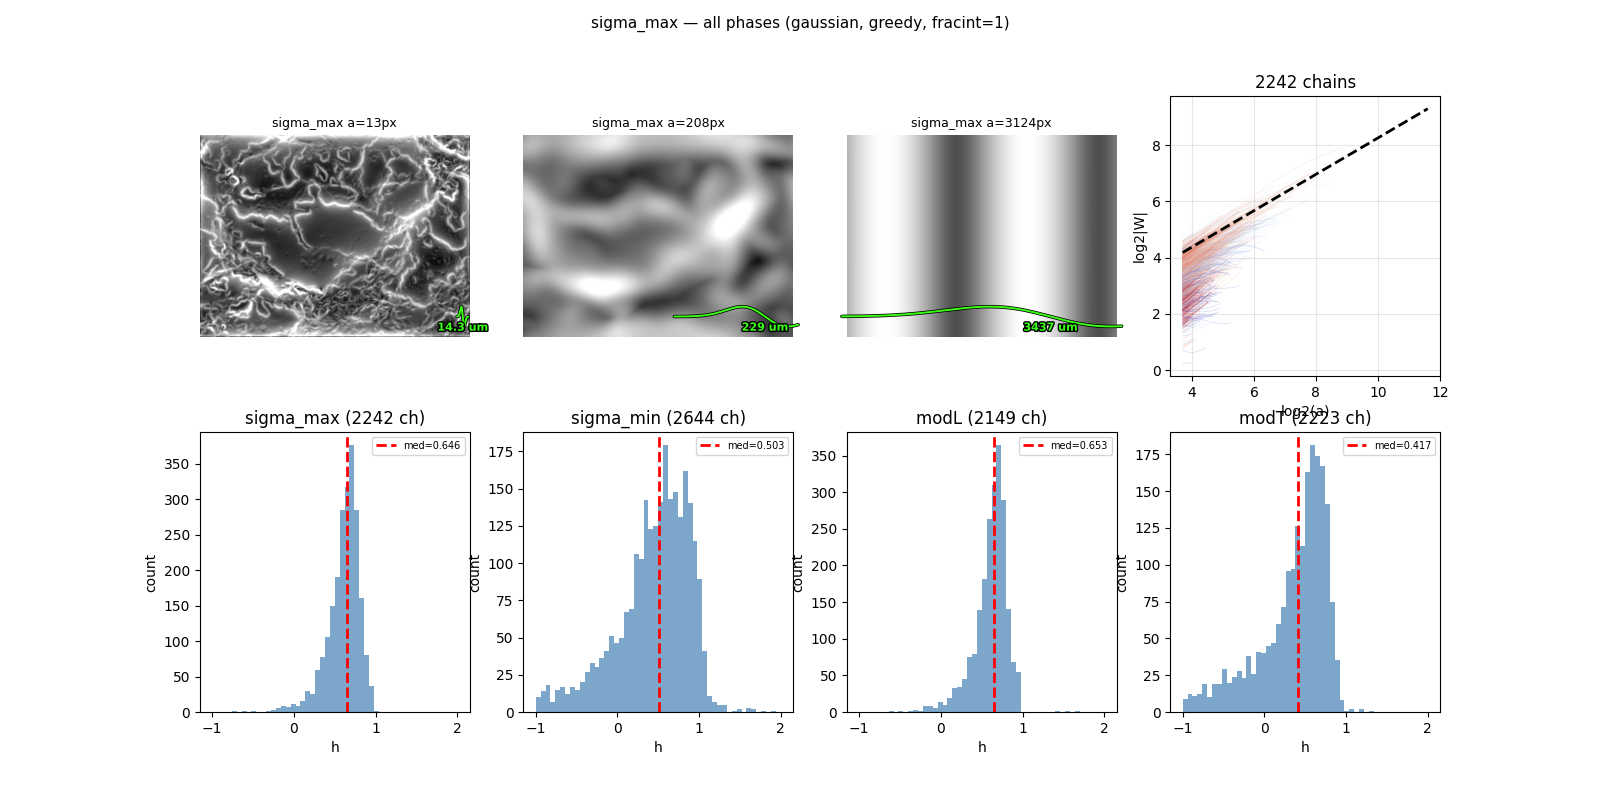

In [23]:
# ===== Tensor WTMM with L/T decomposition: σ_max, σ_min, modL, modT =====
# CWT on combined log-orientation field, tensor SVD at each scale,
# then WTMM on each SVD component separately. Chains labeled by phase.

from xsmurf_wrapper.anchor_chain import chain_and_extract

# ---------- FRACTIONAL INTEGRATION ----------
FRACINT_ALPHA = 1  # 0 = none, 0.5 = mild smoothing, 1.0 = strong, 2.0 = very smooth
# ---------------------------------------------

def fractional_integrate_2d(image, alpha):
    if alpha == 0:
        return image
    ny, nx = image.shape
    kx = np.fft.fftfreq(nx)
    ky = np.fft.fftfreq(ny)
    KX, KY = np.meshgrid(kx, ky)
    K2 = KX**2 + KY**2
    K2[0, 0] = 1.0
    filt = K2 ** (-alpha / 2.0)
    filt[0, 0] = 0.0
    f_hat = np.fft.fft2(image.astype(np.float64))
    g = np.real(np.fft.ifft2(f_hat * filt))
    return g.astype(np.float32)

# Combine per-phase log-orientation into one field
ny, nx = ebsd['euler1'].shape
combined_log = np.zeros((ny, nx, 3), dtype=np.float32)
combined_mask = np.zeros((ny, nx), dtype=bool)
for pid, pdata in phase_log.items():
    combined_log += pdata['log_field']
    combined_mask |= pdata['mask']

print(f'Combined field: {combined_mask.sum()}/{combined_mask.size} indexed pixels')

# CWT on each component of the combined field
# Apply fractional integration if requested
if FRACINT_ALPHA > 0:
    print(f'Fractional integration alpha={FRACINT_ALPHA}...')
    for c in range(3):
        combined_log[..., c] = fractional_integrate_2d(combined_log[..., c], FRACINT_ALPHA)

print('CWT (3 components)...')
derivs = [cwt_2d_f32(combined_log[..., c], scales, pad=PAD, derivs='first',
                      wavelet=WAVELET, verbose=False) for c in range(3)]

# Tensor SVD at each scale → 4 modulus fields
n_sc = len(scales)
svd_fields = {
    'sigma_max': np.zeros((n_sc, ny, nx), dtype=np.float32),
    'sigma_min': np.zeros((n_sc, ny, nx), dtype=np.float32),
    'modL': np.zeros((n_sc, ny, nx), dtype=np.float32),
    'modT': np.zeros((n_sc, ny, nx), dtype=np.float32),
    'arg': np.zeros((n_sc, ny, nx), dtype=np.float32),
}

print('Tensor SVD + L/T decomposition...')
for si in range(n_sc):
    gx1, gy1 = derivs[0]['dx'][si], derivs[0]['dy'][si]
    gx2, gy2 = derivs[1]['dx'][si], derivs[1]['dy'][si]
    gx3, gy3 = derivs[2]['dx'][si], derivs[2]['dy'][si]

    # Full 3x2 SVD → sigma_max, sigma_min
    smax, smin, arg = tensor_svd_3x2(gx1, gy1, gx2, gy2, gx3, gy3)
    svd_fields['sigma_max'][si] = smax
    svd_fields['sigma_min'][si] = smin
    svd_fields['arg'][si] = arg

    # L/T decomposition from the 2x2 sub-tensor of first 2 components
    # Symmetric (L): max(|gx1|, |gy2|, 0.5*|gx2+gy1|)
    # Antisymmetric (T): 0.5*|gx2 - gy1|
    # For 3-component: use all pairs
    modL = np.sqrt(gx1**2 + gy2**2 + 0.25*(gx2 + gy1)**2 +
                   gx3**2 + gy3**2).astype(np.float32)
    modT = (0.5 * np.abs(gx2 - gy1)).astype(np.float32)
    svd_fields['modL'][si] = modL
    svd_fields['modT'][si] = modT

# WTMM on each SVD component
svd_modes = ['sigma_max', 'sigma_min', 'modL', 'modT']
svd_wtmm = {}

for mode in svd_modes:
    print(f'\n  WTMM on {mode}...')
    mod = svd_fields[mode]
    arg = svd_fields['arg']

    ext_images = []
    for si, scale in enumerate(scales):
        dx_r = (mod[si] * np.cos(arg[si])).astype(np.float32)
        dy_r = (mod[si] * np.sin(arg[si])).astype(np.float32)
        ext, _, _ = xsm.wtmm2d(
            xsm.XImage.from_numpy(dx_r),
            xsm.XImage.from_numpy(dy_r), scale, thresh=THRESH)
        ext_images.append(ext)

    chains = chain_and_extract(
        ext_images, scales, method=CHAIN_METHOD,
        a_min=A_MIN, n_oct=N_OCT, n_vox=N_VOX,
        similitude=SIMILITUDE, smooth=False,
        border_percent=BORDER_PCT, dist_frac=DIST_FRAC)
    holders = xsm.compute_holder_exponents(chains)
    h_vals = [h['h'] for h in holders]

    # Label chains by phase
    phase_map = ebsd['phase']
    chains_by_phase = {}
    for ch in chains:
        x0, y0 = int(ch['x'][0]), int(ch['y'][0])
        if 0 <= y0 < ny and 0 <= x0 < nx:
            pid = int(phase_map[y0, x0])
        else:
            pid = 0
        if pid not in chains_by_phase:
            chains_by_phase[pid] = []
        chains_by_phase[pid].append(ch)

    svd_wtmm[mode] = {
        'chains': chains, 'holders': holders,
        'chains_by_phase': chains_by_phase, 'mod': mod,
    }
    if h_vals:
        print(f'    {len(chains)} chains, h med={np.median(h_vals):.3f}')
        for pid, pchains in chains_by_phase.items():
            if pid > 0 and len(pchains) > 5:
                ph = [h['h'] for h in xsm.compute_holder_exponents(pchains)]
                if ph:
                    pname = phase_log.get(pid, {}).get('name', f'P{pid}')
                    print(f'      P{pid} {pname}: {len(pchains)} chains, h med={np.median(ph):.3f}')

print('\nDone.')

# --- Interactive viewer: dropdown for SVD mode × phase ---
mode_dd = widgets.Dropdown(
    options=svd_modes, value='sigma_max',
    description='SVD mode:', style={'description_width': 'initial'})

mask_toggle = widgets.ToggleButtons(
    options=['Mask on', 'Mask off'], value='Mask on', description='Phase mask:')

phase_dd2 = widgets.Dropdown(
    options=[('All phases', 0)] + [(f'P{pid}: {phase_log[pid]["name"]}', pid)
                                    for pid in phase_log if pid in svd_wtmm['sigma_max']['chains_by_phase']],
    value=0, description='Phase:', style={'description_width': 'initial'})

show_idx = [0, len(scales)//2, len(scales)-1]
_fig_svd, _axes_svd = plt.subplots(2, len(show_idx) + 1, figsize=(16, 8))

def _draw_svd(change=None):
    mode = mode_dd.value
    pid_sel = phase_dd2.value
    sw = svd_wtmm[mode]
    log2_s = np.log2(scales)

    if pid_sel == 0:
        chains = sw['chains']
        title_ph = 'all phases'
    else:
        chains = sw['chains_by_phase'].get(pid_sel, [])
        title_ph = f'P{pid_sel} {phase_log.get(pid_sel, {}).get("name", "?")}'

    holders = xsm.compute_holder_exponents(chains)
    h_vals = [h['h'] for h in holders]
    h_lookup = {(int(h['x']), int(h['y'])): h['h'] for h in holders}

    for ax in _axes_svd.flat:
        ax.cla()

    # Top row: modulus images
    for col, si in enumerate(show_idx):
        ax = _axes_svd[0, col]
        m = sw['mod'][si].copy()
        if pid_sel > 0 and 'on' in mask_toggle.value.lower():
            pmask = phase_log.get(pid_sel, {}).get('mask', np.ones((ny, nx), dtype=bool))
            m[~pmask] = np.nan
        vmax = np.nanpercentile(m, 98)
        ax.imshow(m, cmap='gray', vmin=0, vmax=vmax, aspect='equal')
        ax.set_title(f'{mode} a={scales[si]:.0f}px', fontsize=9)
        ax.axis('off')
        add_wavelet_scalebar(ax, scale=scales[si], px_to_unit=px_um,
                              unit_str='um', wavelet=WAVELET)

    # Top right: chain log-log
    ax = _axes_svd[0, -1]
    if h_vals:
        vmin_h, vmax_h = np.percentile(h_vals, [5, 95])
        cm = plt.cm.coolwarm
        nm = plt.Normalize(vmin_h, vmax_h)
        for ch in chains[:1500]:
            n = len(ch['mod'])
            if n < 3: continue
            h = h_lookup.get((int(ch['x'][0]), int(ch['y'][0])), np.nan)
            if not np.isfinite(h): continue
            ax.plot(ch['log2_scales'], ch['log2_mod'], '-',
                    color=cm(nm(h)), alpha=0.2, lw=0.5)
        mid = len(log2_s) // 2
        mods_mid = [ch['log2_mod'][min(mid, len(ch['mod'])-1)]
                    for ch in chains if len(ch['mod']) > mid]
        if mods_mid:
            h_med = np.median(h_vals)
            ref = h_med * (log2_s - log2_s[mid]) + np.median(mods_mid)
            ax.plot(log2_s, ref, 'k--', lw=2)
    ax.set(xlabel='log2(a)', ylabel='log2|W|', title=f'{len(chains)} chains')
    ax.grid(True, alpha=0.3)

    # Bottom: histograms for all 4 modes at the selected phase
    for col, m_name in enumerate(svd_modes):
        ax = _axes_svd[1, col]
        if pid_sel == 0:
            ch_m = svd_wtmm[m_name]['chains']
        else:
            ch_m = svd_wtmm[m_name]['chains_by_phase'].get(pid_sel, [])
        hv = [h['h'] for h in xsm.compute_holder_exponents(ch_m)]
        if hv:
            ax.hist(hv, bins=50, range=(-1, 2), alpha=0.7, color='steelblue')
            ax.axvline(np.median(hv), color='red', ls='--', lw=2,
                       label=f'med={np.median(hv):.3f}')
            ax.legend(fontsize=7)
        ax.set(xlabel='h', ylabel='count', title=f'{m_name} ({len(ch_m)} ch)')

    _fig_svd.suptitle(f'{mode} — {title_ph} ({WAVELET}, {CHAIN_METHOD}, fracint={FRACINT_ALPHA})', fontsize=11)
    _fig_svd.canvas.draw_idle()

mode_dd.observe(_draw_svd, names='value')
phase_dd2.observe(_draw_svd, names='value')
mask_toggle.observe(_draw_svd, names='value')
display(widgets.VBox([widgets.HBox([mode_dd, phase_dd2]), mask_toggle]))
_draw_svd()

In [24]:
# ===== Precompute partition functions for SVD modes x phases =====

from xsmurf_wrapper.partition import extract_hq_Dq_from_plateaus

q_list_full = np.arange(-10, 11, 1)
n_q = len(q_list_full)
log2c = np.log(2.0)

def build_hd_from_chains(chains, scales_list):
    n_sc = len(scales_list)
    STq_std = np.zeros((n_q, n_sc), dtype=np.float64)
    STqlogT_std = np.zeros((n_q, n_sc), dtype=np.float64)
    STq_cmax = np.zeros((n_q, n_sc), dtype=np.float64)
    STqlogT_cmax = np.zeros((n_q, n_sc), dtype=np.float64)
    for ch in chains:
        n_ch = len(ch['mod'])
        running_max = 0.0
        for si in range(min(n_ch, n_sc)):
            m = abs(float(ch['mod'][si]))
            if m <= 0: continue
            if m > running_max: running_max = m
            log_m = np.log(m)
            log_m_sup = np.log(max(running_max, 1e-30))
            for qi, q in enumerate(q_list_full):
                mq = m ** q if q != 0 else 1.0
                STq_std[qi, si] += mq
                STqlogT_std[qi, si] += log_m * mq
                mq_sup = running_max ** q if q != 0 else 1.0
                STq_cmax[qi, si] += mq_sup
                STqlogT_cmax[qi, si] += log_m_sup * mq_sup
    def _build(STq, STqlogT):
        tau = np.full((n_q, n_sc), np.nan)
        h = np.full((n_q, n_sc), np.nan)
        D = np.full((n_q, n_sc), np.nan)
        vZ = STq > 0
        tau[vZ] = np.log(STq[vZ]) / log2c
        h[vZ] = STqlogT[vZ] / (log2c * STq[vZ])
        for qi, q in enumerate(q_list_full):
            for si in range(n_sc):
                if STq[qi, si] > 0:
                    D[qi, si] = (q * STqlogT[qi, si]
                                 - STq[qi, si] * np.log(STq[qi, si])) / (STq[qi, si] * log2c)
        return {'tau_qa': tau, 'h_qa': h, 'D_qa': D,
                'q_list': q_list_full,
                'scales': np.array(scales_list),
                'log2_scales': np.log2(np.array(scales_list))}
    return _build(STq_std, STqlogT_std), _build(STq_cmax, STqlogT_cmax)

pf_data = {}
for mode in svd_modes:
    sw = svd_wtmm[mode]
    print(f'{mode}: all ({len(sw["chains"])} ch)...')
    hd_s, hd_c = build_hd_from_chains(sw['chains'], scales)
    pf_data[(mode, 0)] = {'hd_std': hd_s, 'hd_cmax': hd_c, 'chains': sw['chains']}
    for pid, pch in sw['chains_by_phase'].items():
        if pid > 0 and len(pch) >= 10:
            pname = phase_log.get(pid, {}).get('name', f'P{pid}')
            print(f'  P{pid} {pname} ({len(pch)} ch)...')
            hs, hc = build_hd_from_chains(pch, scales)
            pf_data[(mode, pid)] = {'hd_std': hs, 'hd_cmax': hc, 'chains': pch}

print(f'Precomputed {len(pf_data)} partition functions.')

sigma_max: all (2242 ch)...
  P1 Quartz-new (1786 ch)...
sigma_min: all (2644 ch)...
  P1 Quartz-new (2215 ch)...
modL: all (2149 ch)...
  P1 Quartz-new (1692 ch)...
modT: all (2223 ch)...
  P1 Quartz-new (1817 ch)...
Precomputed 8 partition functions.


LEFT-click = min scale | RIGHT-click = max scale


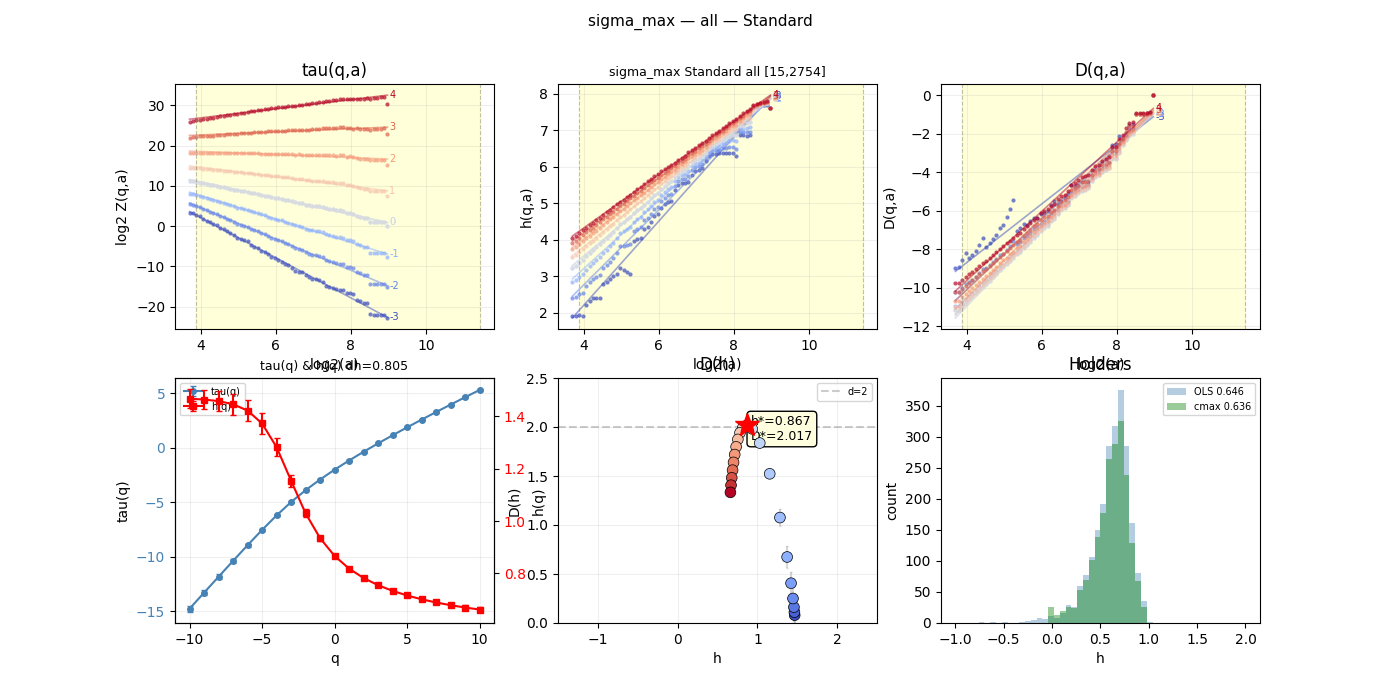

In [25]:
%matplotlib widget

pf_state = {'scale_min': None, 'scale_max': None}

# Build dropdown options
phase_opts = [('All phases', 0)]
for pid in phase_log:
    if any((m, pid) in pf_data for m in svd_modes):
        phase_opts.append((f'P{pid}: {phase_log[pid]["name"]}', pid))

pf_mode_dd = widgets.Dropdown(options=svd_modes, value='sigma_max',
    description='SVD:', style={'description_width': 'initial'}, layout=widgets.Layout(width='200px'))
pf_phase_dd = widgets.Dropdown(options=phase_opts, value=0,
    description='Phase:', style={'description_width': 'initial'}, layout=widgets.Layout(width='300px'))
pf_cmax = widgets.ToggleButtons(options=['Standard', 'Chainmax'], value='Standard', description='PF:')

q_show = np.array([-3, -2, -1, 0, 0.5, 1, 2, 3, 4])
colors_q = plt.cm.coolwarm(np.linspace(0, 1, len(q_show)))

_fig_pf, _axes_pf = plt.subplots(2, 3, figsize=(14, 7), gridspec_kw={'height_ratios': [1, 1]})
_axes_pf_top = _axes_pf[0]
_ax_pf_tau = _axes_pf[1, 0]
_ax_pf_dh = _axes_pf[1, 1]
_ax_pf_hist = _axes_pf[1, 2]
_pf_twin = [None]

def _pf_click(event):
    if event.inaxes is None or event.xdata is None: return
    if event.inaxes not in _axes_pf_top: return
    a = 2 ** event.xdata
    if event.button == 1: pf_state['scale_min'] = a
    elif event.button == 3: pf_state['scale_max'] = a
    if (pf_state['scale_min'] is not None and pf_state['scale_max'] is not None
            and pf_state['scale_min'] > pf_state['scale_max']):
        pf_state['scale_min'], pf_state['scale_max'] = pf_state['scale_max'], pf_state['scale_min']
    pf_draw()
_fig_pf.canvas.mpl_connect('button_press_event', _pf_click)

def pf_draw(*_):
    mode = pf_mode_dd.value
    pid = pf_phase_dd.value
    key = (mode, pid)
    if key not in pf_data:
        print(f'No data for {key}')
        return
    v = pf_data[key]
    hd = v['hd_std'] if 'Standard' in pf_cmax.value else v['hd_cmax']
    chains = v['chains']
    scales_arr = hd['scales']
    log2_s = hd['log2_scales']
    cmax_mode = pf_cmax.value

    if pf_state['scale_min'] is None: pf_state['scale_min'] = scales_arr[2]
    if pf_state['scale_max'] is None: pf_state['scale_max'] = scales_arr[-3]
    smin, smax = pf_state['scale_min'], pf_state['scale_max']
    s_mask = (scales_arr >= smin) & (scales_arr <= smax)

    for ax in _axes_pf_top: ax.cla()
    for panel, (key_name, ylabel, title) in enumerate([
            ('tau_qa', 'log2 Z(q,a)', 'tau(q,a)'),
            ('h_qa', 'h(q,a)', 'h(q,a)'),
            ('D_qa', 'D(q,a)', 'D(q,a)')]):
        ax = _axes_pf_top[panel]
        for qi_val, color in zip(q_show, colors_q):
            idx = np.argmin(np.abs(hd['q_list'] - qi_val))
            y = hd[key_name][idx]
            valid = np.isfinite(y)
            if valid.sum() < 2: continue
            ax.plot(log2_s[valid], y[valid], 'o', color=color, ms=3, alpha=0.7, mec='none')
            yf = y[s_mask]; xf = log2_s[s_mask]; vf = np.isfinite(yf)
            if vf.sum() >= 2:
                try:
                    sl, ic = np.polyfit(xf[vf], yf[vf], 1)
                    ax.plot(log2_s[valid], sl*log2_s[valid]+ic, '-', color=color, lw=1.2, alpha=0.5)
                    ax.text(log2_s[valid][-1]+0.05, sl*log2_s[valid][-1]+ic,
                            f'{hd["q_list"][idx]:g}', color=color, fontsize=7, va='center')
                except: pass
        ax.axvspan(np.log2(smin), np.log2(smax), alpha=0.15, color='yellow', zorder=0)
        ax.axvline(np.log2(smin), color='gray', ls='--', lw=0.8, alpha=0.5)
        ax.axvline(np.log2(smax), color='gray', ls='--', lw=0.8, alpha=0.5)
        ax.set(xlabel='log2(a)', ylabel=ylabel, title=title)
        ax.grid(True, alpha=0.2)
    ph_label = 'all' if pid == 0 else f'P{pid}'
    _axes_pf_top[1].set_title(f'{mode} {cmax_mode} {ph_label} [{smin:.0f},{smax:.0f}]', fontsize=9)

    _ax_pf_tau.cla()
    if _pf_twin[0] is not None: _pf_twin[0].remove(); _pf_twin[0] = None
    _ax_pf_dh.cla()
    _ax_pf_hist.cla()

    if s_mask.sum() >= 2:
        res = extract_hq_Dq_from_plateaus(hd, scale_range=(smin, smax))
        q = res['q_list']
        valid = np.isfinite(res['h']) & np.isfinite(res['D']) & np.isfinite(res['tau'])
        if valid.any():
            _ax_pf_tau.errorbar(q[valid], res['tau'][valid], yerr=res['tau_err'][valid],
                               fmt='o-', color='steelblue', ms=4, capsize=2, lw=1.5, label='tau(q)')
            _ax_pf_tau.set(xlabel='q', ylabel='tau(q)')
            _ax_pf_tau.tick_params(axis='y', labelcolor='steelblue')
            _ax_pf_tau.grid(True, alpha=0.2)
            ax2 = _ax_pf_tau.twinx(); _pf_twin[0] = ax2
            ax2.errorbar(q[valid], res['h'][valid], yerr=res['h_err'][valid],
                         fmt='s-', color='red', ms=4, capsize=2, lw=1.5, label='h(q)')
            ax2.set(ylabel='h(q)')
            ax2.tick_params(axis='y', labelcolor='red')
            h_w = res['h'][valid].max() - res['h'][valid].min()
            _ax_pf_tau.set_title(f'tau(q) & h(q) dh={h_w:.3f}', fontsize=9)
            l1, lb1 = _ax_pf_tau.get_legend_handles_labels()
            l2, lb2 = ax2.get_legend_handles_labels()
            _ax_pf_tau.legend(l1+l2, lb1+lb2, loc='upper left', fontsize=7)

            _ax_pf_dh.scatter(res['h'][valid], res['D'][valid], c=q[valid], cmap='coolwarm',
                              s=60, edgecolors='black', linewidths=0.5, zorder=5)
            _ax_pf_dh.errorbar(res['h'][valid], res['D'][valid],
                            xerr=res['h_err'][valid], yerr=res['D_err'][valid],
                            fmt='.', color='gray', ms=1, capsize=1, alpha=0.3)
            _ax_pf_dh.axhline(2, color='gray', ls='--', alpha=0.4, label='d=2')
            pk = np.argmax(res['D'][valid])
            _ax_pf_dh.plot(res['h'][valid][pk], res['D'][valid][pk], 'r*', ms=18, zorder=10)
            _ax_pf_dh.annotate(
                f"h*={res['h'][valid][pk]:.3f}\nD*={res['D'][valid][pk]:.3f}",
                xy=(res['h'][valid][pk], res['D'][valid][pk]),
                xytext=(res['h'][valid][pk]+0.05, res['D'][valid][pk]-0.15),
                fontsize=9, arrowprops=dict(arrowstyle='->', color='red'),
                bbox=dict(boxstyle='round', fc='lightyellow'))
            _ax_pf_dh.set(xlabel='h', ylabel='D(h)', title='D(h)',
                         xlim=(-1.5, 2.5), ylim=(0, 2.5))
            _ax_pf_dh.legend(fontsize=7)
            _ax_pf_dh.grid(True, alpha=0.2)

    h_ols = [h['h'] for h in xsm.compute_holder_exponents(chains)]
    h_cmax_v = [h['h'] for h in compute_holder_chainmax(chains)]
    if h_ols:
        _ax_pf_hist.hist(h_ols, bins=50, range=(-1, 2), alpha=0.4,
                         label=f'OLS {np.median(h_ols):.3f}', color='steelblue')
    if h_cmax_v:
        _ax_pf_hist.hist(h_cmax_v, bins=50, range=(-1, 2), alpha=0.4,
                         label=f'cmax {np.median(h_cmax_v):.3f}', color='green')
    _ax_pf_hist.set(xlabel='h', ylabel='count', title='Holders')
    _ax_pf_hist.legend(fontsize=7)

    _fig_pf.suptitle(f'{mode} — {ph_label} — {cmax_mode}', fontsize=11)
    _fig_pf.canvas.draw_idle()

pf_mode_dd.observe(pf_draw, names='value')
pf_phase_dd.observe(pf_draw, names='value')
pf_cmax.observe(pf_draw, names='value')
print('LEFT-click = min scale | RIGHT-click = max scale')
display(widgets.VBox([widgets.HBox([pf_mode_dd, pf_phase_dd]), pf_cmax]))
pf_draw()

Local scaling exponents computed for 8 combinations


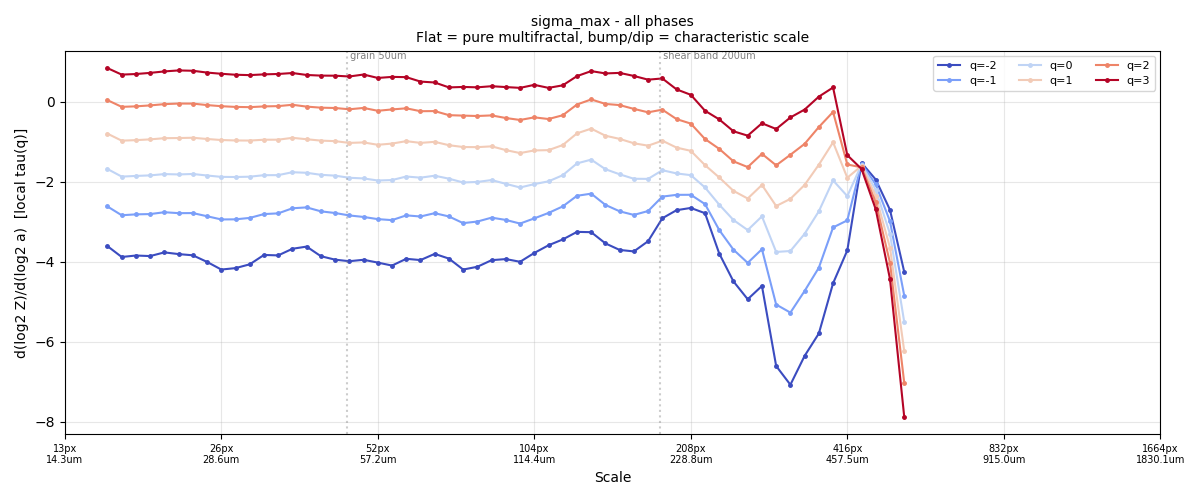

In [26]:
# ===== Local scaling exponent: characteristic scale detection =====
# Flat = pure multifractal, deviation = characteristic scale

def local_scaling_exponent(hd, q_list_show, window=3):
    log2_s = hd['log2_scales']
    tau_qa = hd['tau_qa']
    n_sc = len(log2_s)
    results = {}
    for q in q_list_show:
        qi = np.argmin(np.abs(hd['q_list'] - q))
        y = tau_qa[qi]
        local_tau = np.full(n_sc, np.nan)
        for i in range(window, n_sc - window):
            sl = slice(i - window, i + window + 1)
            x_loc = log2_s[sl]
            y_loc = y[sl]
            v = np.isfinite(y_loc)
            if v.sum() >= 3:
                local_tau[i] = np.polyfit(x_loc[v], y_loc[v], 1)[0]
        results[q] = local_tau
    return results

q_show_lse = np.array([-2, -1, 0, 1, 2, 3])
colors_lse = plt.cm.coolwarm(np.linspace(0, 1, len(q_show_lse)))
step_um = float(meta['xstep'])

# Precompute for all modes x phases
lse_cache = {}
for (mode, pid), v in pf_data.items():
    lse_cache[(mode, pid)] = local_scaling_exponent(v['hd_std'], q_show_lse, window=3)
print(f'Local scaling exponents computed for {len(lse_cache)} combinations')

# --- Interactive viewer ---
lse_mode_dd = widgets.Dropdown(options=svd_modes, value='sigma_max',
    description='SVD:', style={'description_width': 'initial'}, layout=widgets.Layout(width='200px'))
lse_phase_dd = widgets.Dropdown(
    options=[('All phases', 0)] + [(f'P{pid}: {phase_log[pid]["name"]}', pid)
             for pid in phase_log if any((m, pid) in lse_cache for m in svd_modes)],
    value=0, description='Phase:', style={'description_width': 'initial'},
    layout=widgets.Layout(width='300px'))

_fig_lse, _ax_lse = plt.subplots(1, 1, figsize=(12, 5))

def _draw_lse(change=None):
    mode = lse_mode_dd.value
    pid = lse_phase_dd.value
    key = (mode, pid)
    _ax_lse.cla()

    if key not in lse_cache:
        _ax_lse.set_title(f'No data for {mode} P{pid}')
        _fig_lse.canvas.draw_idle()
        return

    lse = lse_cache[key]
    log2_s = np.log2(scales)

    for qi, (q, color) in enumerate(zip(q_show_lse, colors_lse)):
        vals = lse[q]
        v = np.isfinite(vals)
        if v.any():
            _ax_lse.plot(log2_s[v], vals[v], '.-', color=color, ms=5, lw=1.5,
                         label=f'q={q:.0f}')

    _ax_lse.set_ylabel('d(log2 Z)/d(log2 a)  [local tau(q)]')
    _ax_lse.grid(True, alpha=0.3)
    _ax_lse.legend(fontsize=8, ncol=3, loc='best')

    # Bottom x-axis: log2(a) with um labels
    physical_um = np.array(scales) * step_um
    tick_positions = log2_s[::max(1, len(scales)//8)]
    tick_labels = [f'{2**lv:.0f}px\n{2**lv*step_um:.1f}um' for lv in tick_positions]
    _ax_lse.set_xticks(tick_positions)
    _ax_lse.set_xticklabels(tick_labels, fontsize=7)
    _ax_lse.set_xlabel('Scale')

    # Mark microstructural scales
    xlim = _ax_lse.get_xlim()
    for lam, name in [(5, 'subgrain'), (50, 'grain'), (200, 'shear band')]:
        log2_lam = np.log2(lam / step_um)
        if xlim[0] < log2_lam < xlim[1]:
            _ax_lse.axvline(log2_lam, color='gray', ls=':', alpha=0.4)
            _ax_lse.text(log2_lam, _ax_lse.get_ylim()[1], f' {name} {lam}um',
                         fontsize=7, va='top', ha='left', alpha=0.5)

    ph_label = 'all phases' if pid == 0 else f'P{pid} {phase_log.get(pid, {}).get("name", "?")}'
    _ax_lse.set_title(f'{mode} - {ph_label}\n'
                      f'Flat = pure multifractal, bump/dip = characteristic scale',
                      fontsize=10)
    _fig_lse.tight_layout()
    _fig_lse.canvas.draw_idle()

lse_mode_dd.observe(_draw_lse, names='value')
lse_phase_dd.observe(_draw_lse, names='value')
display(widgets.HBox([lse_mode_dd, lse_phase_dd]))
_draw_lse()